# 데이터기반공학해석 (2026-2학기) — 과제 1회차 Part A: SVD · POD

| 문항 | 내용 | 필요한 데이터 |
|---|---|---|
| A | Code 1.1(절단 SVD)을 자기 사진에 적용 — r = 5, 20, 100 표 + 식 (2) 검증 | `mongehodu.jpg` (이 노트북과 같은 폴더) |
| B | Code 1.10 변형(택1-①): 잡음 γ = 0.5, 2 에서 경판정 vs 누적합 90% | 없음(난수 생성) |
| D | 개인 탐구: CNT 공진기 FRC 주기응답 스냅샷 행렬의 SVD/POD | `result_0819/…AC_0.19…HBM_coeffs_branch01/02.csv` |


In [1]:
# 공통 환경 설정 ---------------------------------------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import os, warnings
warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "font.family": "DejaVu Sans"})   # 한글 폰트가 있으면 'Malgun Gothic' 으로 바꿔도 됨

NB_DIR   = Path.cwd()                                   # 이 노트북이 있는 폴더
PHOTO    = NB_DIR / "mongehodu.jpg"                      # A: 자기 사진 (없으면 대체 이미지 사용)
DATA_DIR = Path(os.environ.get("ISOLA_DIR",             # D: deflated_continuation/result_0819
             Path.home() / "Desktop" / "Isola" / "deflated_continuation" / "result_0819"))
print("notebook dir :", NB_DIR)
print("result_0819  :", DATA_DIR, "(exists)" if DATA_DIR.exists() else "(NOT FOUND — 경로를 확인하세요)")


notebook dir : c:\Users\smsm0\Desktop\data_driven_analysis
result_0819  : C:\Users\smsm0\Desktop\Isola\deflated_continuation\result_0819 (exists)


## 0. 2주차 정리 — "데이터 행렬 $X$를 어떤 기저로 쓸 것인가"

### 0.1 SVD의 정의 [B&K §1.1]
임의의 $X\in\mathbb{R}^{n\times m}$에 대해 $X^TX$, $XX^T$는 대칭이고 고유값이 0 이상이다. 둘의 고유벡터를 각각 $V$, $U$의 열로, 공통 고유값의 양의 제곱근을 $\sigma_1\ge\sigma_2\ge\cdots\ge0$으로 두면

$$X = U\Sigma V^T,\qquad U^TU=I,\; V^TV=I,\; \Sigma=\begin{bmatrix}\hat\Sigma\\0\end{bmatrix},\; \hat\Sigma=\mathrm{diag}(\sigma_1,\dots,\sigma_m). \tag{1}$$

기하학적으로 $X$ = 회전($V^T$) – 축방향 늘림($\Sigma$) – 회전($U$). 손계산 예 1: $X=\begin{bmatrix}3&0\\4&5\end{bmatrix}$ → $\sigma_1=3\sqrt5,\ \sigma_2=\sqrt5$.

### 0.2 economy SVD = POD [B&K §1.1, §1.3]
열이 스냅샷 $x_k\in\mathbb{R}^n$이고 $n\gg m$이면 $U$의 앞 $m$열 $\hat U$만 남는다: $X=\hat U\hat\Sigma V^T=\sum_{k=1}^m \sigma_k u_k v_k^T$.
$u_k$ = 공간 모드(POD 모드), $\sigma_k v_k^T$ = 모드 $k$의 시간 계수. **스냅샷 방법**: $m\times m$ 행렬 $X^TX=V\hat\Sigma^2V^T$를 고유분해하고 $\hat U=XV\hat\Sigma^{-1}$ [B&K (1.14)].

### 0.3 절단 SVD와 Eckart–Young [B&K §1.2, §1.7]
앞 $r$개만 남긴 $\tilde X=\sum_{k\le r}\sigma_ku_kv_k^T$는 랭크 $r$ 행렬 가운데 $X$에 가장 가깝고(Frobenius·2-노름 모두), 오차는 **버린 특이값**이 정한다:

$$\|X-\tilde X\|_F^2=\sum_{k>r}\sigma_k^2,\qquad \|X-\tilde X\|_2=\sigma_{r+1},\qquad
\frac{\|X-\tilde X\|_F}{\|X\|_F}=\sqrt{1-E(r)},\quad E(r)=\frac{\sum_{k\le r}\sigma_k^2}{\sum_k\sigma_k^2}. \tag{2}$$

> 주의: 에너지 99 %는 오차 1 %가 아니라 $\sqrt{1-0.99}=10\,\%$. 교재 그림 1.4(b)의 곡선은 $\sigma$의 누적합(제곱 아님)이다.

**랭크 $r$ 고르기** [B&K §1.7]: (i) 에너지 $E(r)\ge0.9$–$0.99$, (ii) 특이값 그래프의 엘보, (iii) **경판정(hard threshold, Gavish–Donoho 2014)** — $n\times n$ 행렬에 표준편차 $\gamma$의 가우시안 잡음이 있으면 $\tau=\frac{4}{\sqrt3}\sqrt n\,\gamma$ [B&K (1.44)], $\gamma$를 모르면 $\tau\approx2.858\,\sigma_{\rm med}$ [B&K (1.47)]. 직사각 $m\times n$($\beta=m/n$)이면 $\tau=\omega(\beta)\,\sigma_{\rm med}$, $\omega(\beta)\approx0.56\beta^3-0.95\beta^2+1.82\beta+1.43$.

### 0.4 의사역행렬·최소제곱·조건수 [B&K §1.4]
$Ax=b$ ($n>p$)의 최소제곱 해 $\tilde x=A^\dagger b$, $A^\dagger=V\hat\Sigma^{-1}\hat U^T$ (`pinv`). 조건수 $\kappa=\sigma_{\max}/\sigma_{\min}$: $b$의 상대오차가 최대 $\kappa$배로 증폭. 작은 특이값을 잘라낸 절단 의사역행렬이 정칙화.

### 0.5 PCA [B&K §1.5]
행 = 관측, 열 = 변수인 $X$에서 평균을 뺀 $B=X-\bar x$, 공분산 $C=B^TB/(n-1)$. $B=U\Sigma V^T$이면 주성분 = $V$의 열, 분산 $\lambda_k=\sigma_k^2/(n-1)$. **PCA = 평균을 뺀 데이터의 SVD.** 평균을 빼지 않으면 첫 주성분이 평균 방향이 된다.

### 0.6 고유얼굴과 정렬 [B&K §1.6–1.7]
정렬된 앙상블(얼굴·유동장·진동 응답)에서는 데이터 기저가 수백 모드로 공간을 담는다. 그러나 SVD는 행·열의 변수분리이므로 **이동·회전·확대가 있으면 저랭크 구조가 사라진다**(흰 정사각형: 랭크 1 → 10° 회전 시 176개 특이값).

### 0.7 고정 기저 — Fourier · DFT · 웨이블릿 [B&K Ch.2]
* Fourier 급수 $f=\frac{a_0}2+\sum_k(a_k\cos kx+b_k\sin kx)$, $a_k=\langle f,\cos kx\rangle/\|\cos kx\|^2$ (3) — 정규직교 기저에 대한 투영. SVD와 다른 점은 **기저를 데이터를 보기 전에 정했다**는 것뿐. $k\le K$에서 자르면 Parseval에 의해 오차² = 버린 계수의 제곱합 ((2)와 같은 문장).
* DFT $\hat f_k=\sum_j f_je^{-i2\pi jk/n}$ (4), FFT는 $O(n\log n)$, PSD$_k=|\hat f_k|^2/n$. 손계산 예 2: $f=(1,0,-1,0)\Rightarrow\hat f=(0,2,0,2)$.
* Haar 웨이블릿: 이웃 값의 평균·차이를 반복(DWT). 에지 근처에서만 계수가 커서 Gibbs를 일으키던 신호가 희소해진다. 손계산 예 3: $x=(4,6,10,12)\Rightarrow a_2=16,\ d_2=-6,\ d_1=(-1.41,-1.41)$.

### 0.8 결론 — 같은 사진, 세 기저 [B&K 표 2]
| | 데이터 기저 — SVD/POD/PCA | 고정 기저 — Fourier/웨이블릿 |
|---|---|---|
| 기저를 누가 정하나 | 데이터: $XX^T$의 고유벡터 $u_k$ | 미리: $e^{i\omega x}$, $\psi_{a,b}$ |
| 계수 / 오차 | $U^TX$ / 버린 $\sigma_k$의 제곱합 (2) | $\mathcal Ff$, $\langle f,\psi_{a,b}\rangle$ / 버린 계수의 제곱합 (Parseval) |
| 최적성 | 이 행렬의 랭크-$r$ 근사에서 최적 (Eckart–Young) | 함수 클래스에서 희소: 매끄러운 신호(Fourier), 에지(웨이블릿) |
| 비용 | $O(nm^2)$, 데이터마다 다시 | $O(n\log n)$, 새 데이터에도 그대로 |

셋 다 "정규직교 기저에 투영하고 큰 계수만 남기는 것". **사진 한 장은 고정 기저가 낫고, 정렬된 앙상블(얼굴·유동장·진동 응답)은 데이터 기저가 낫다** — D에서 진동 응답 앙상블로 이것을 확인한다.


### 0.9 손유도 (필수) — 요지

**(1) $X^TX$의 고유값이 $\sigma_k^2$임과 (2)의 두 오차 공식.**
$X=U\Sigma V^T$를 대입하면 $X^TX=V\Sigma^TU^TU\Sigma V^T=V(\Sigma^T\Sigma)V^T$. $V$가 직교이므로 이것은 $X^TX$의 고유분해이고 고유값은 $\Sigma^T\Sigma$의 대각 = $\sigma_k^2$, 고유벡터 = $V$의 열. (같은 방법으로 $XX^T=U\Sigma\Sigma^TU^T$.)
오차: $X-\tilde X=\sum_{k>r}\sigma_ku_kv_k^T=U\,\mathrm{diag}(0,\dots,0,\sigma_{r+1},\dots)\,V^T$. Frobenius 노름은 직교변환에 불변($\|UAV^T\|_F=\|A\|_F$)이므로 $\|X-\tilde X\|_F^2=\sum_{k>r}\sigma_k^2$; 2-노름(최대 특이값)은 남은 것 중 최대인 $\sigma_{r+1}$. 또 $\|X\|_F^2=\sum_k\sigma_k^2$이므로 $\|X-\tilde X\|_F^2/\|X\|_F^2=1-E(r)$.

**(2) 직교성에서 $a_k$ 유도와 Code 2.1의 한 줄.**
$[-\pi,\pi)$에서 $\int\cos jx\cos kx\,dx=\pi\delta_{jk}$, $\int\cos jx\sin kx\,dx=0$. $f=\frac{a_0}2+\sum(a_k\cos kx+b_k\sin kx)$의 양변에 $\cos kx$를 곱해 적분하면 다른 항은 모두 0이고 $\int f\cos kx\,dx=a_k\pi$ → $a_k=\frac1\pi\int f\cos kx\,dx=\langle f,\cos kx\rangle/\|\cos kx\|^2$.
구간 $[-L,L]$, 격자 간격 $dx$에서 적분을 Riemann 합으로 바꾸면 $a_k\approx\frac1L\sum_j f_j\cos(\pi kx_j/L)\,dx$ — 이것이 교재 Code 2.1의 `A(k)=sum(f.*cos(pi*k*x/L))*dx` (교재는 $1/L$을 뒤에서 곱함).

**(3) 손계산 예 1–3의 검산** — 아래 셀.


In [2]:
# 손계산 예 1 — 2x2 SVD ---------------------------------------------------
X = np.array([[3., 0.], [4., 5.]])
U, s, Vt = np.linalg.svd(X)
print("sigma =", s, "  (손계산: 3*sqrt5 =", 3*np.sqrt(5), ", sqrt5 =", np.sqrt(5), ")")
print("U =\n", U, "\nV^T =\n", Vt)
X1 = s[0] * np.outer(U[:, 0], Vt[0])                  # 랭크-1 근사
print("rank-1 approx =\n", X1)
print("||X-X1||_F^2 =", np.sum((X - X1)**2), " = sigma_2^2 =", s[1]**2)
print("||X-X1||_2   =", np.linalg.norm(X - X1, 2), " = sigma_2 =", s[1])
print("UΣV^T == X ?", np.allclose(U @ np.diag(s) @ Vt, X), " u1·u2 =", U[:,0] @ U[:,1])

# 손계산 예 2 — n=4 DFT -------------------------------------------------------
f = np.array([1, 0, -1, 0])
F = np.fft.fft(f)
print("\nfft([1 0 -1 0]) =", np.round(F.real, 10), "  (손계산: (0,2,0,2))")
print("Parseval: sum|f|^2 =", np.sum(f**2), ",  (1/n) sum|F|^2 =", np.sum(np.abs(F)**2)/4)

# 손계산 예 3 — 4점 Haar DWT (pywt 없이 직접 구현) -------------------------------
def haar_step(x):
    x = np.asarray(x, float)
    return (x[0::2] + x[1::2])/np.sqrt(2), (x[0::2] - x[1::2])/np.sqrt(2)   # 근사 a, 세부 d
x = np.array([4, 6, 10, 12])
a1, d1 = haar_step(x); a2, d2 = haar_step(a1)
print("\n1단계: a =", a1, " d =", d1)
print("2단계: a2 =", a2, " d2 =", d2)
print("계수 제곱합 =", a2@a2 + d2@d2 + d1@d1, " = sum x^2 =", x@x, "(Parseval)")
# 작은 두 계수 d1 을 버리고 복원
def ihaar_step(a, d):
    out = np.empty(2*len(a)); out[0::2] = (a + d)/np.sqrt(2); out[1::2] = (a - d)/np.sqrt(2); return out
x_rec = ihaar_step(ihaar_step(a2, d2), np.zeros_like(d1))
print("d1 버리고 복원 =", x_rec, " 오차 제곱합 =", np.sum((x - x_rec)**2), " = 버린 계수 제곱합 =", d1@d1)


sigma = [6.7082 2.2361]   (손계산: 3*sqrt5 = 6.708203932499369 , sqrt5 = 2.23606797749979 )
U =
 [[-0.3162 -0.9487]
 [-0.9487  0.3162]] 
V^T =
 [[-0.7071 -0.7071]
 [-0.7071  0.7071]]
rank-1 approx =
 [[1.5 1.5]
 [4.5 4.5]]
||X-X1||_F^2 = 5.0  = sigma_2^2 = 4.999999999999998
||X-X1||_2   = 2.23606797749979  = sigma_2 = 2.2360679774997894
UΣV^T == X ? True  u1·u2 = 1.1102230246251565e-16

fft([1 0 -1 0]) = [0. 2. 0. 2.]   (손계산: (0,2,0,2))
Parseval: sum|f|^2 = 2 ,  (1/n) sum|F|^2 = 2.0

1단계: a = [ 7.0711 15.5563]  d = [-1.4142 -1.4142]
2단계: a2 = [16.]  d2 = [-6.]
계수 제곱합 = 295.99999999999994  = sum x^2 = 296 (Parseval)
d1 버리고 복원 = [ 5.  5. 11. 11.]  오차 제곱합 = 4.0  = 버린 계수 제곱합 = 3.999999999999999


## A. 교재 예제 재현 (필수) — Code 1.1을 자기 사진에 적용

**문제.** Code 1.1(개 사진의 절단 SVD)을 자기 사진에 적용해 $r=5,20,100$의 **저장량·상대오차·에너지 표**를 만들고, 식 (2)의 두 오차 공식

$$\|X-\tilde X_r\|_F^2=\sum_{k>r}\sigma_k^2,\qquad \|X-\tilde X_r\|_2=\sigma_{r+1}$$

이 실측 수치와 맞음을 보인다. 저장량은 $r(n+m+1)/(nm)$ (B&K 식 1.11의 저장 개수 비율).

**준비.** 이 노트북과 같은 폴더에 `mongehodu.jpg`를 둔다. 없으면 대체 이미지(scikit-image 샘플, 그것도 없으면 result_0819의 FRC 그림)를 쓰고 경고를 출력한다.


image source: mongehodu.jpg,   X shape = 412 x 412


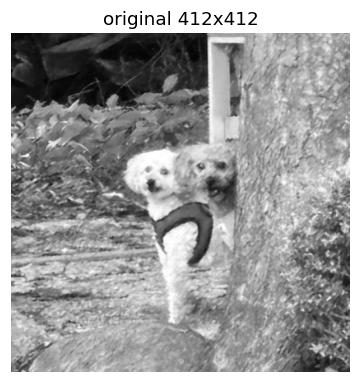

In [3]:
# A-1. 사진 읽기 → 흑백 행렬 X (n x m) --------------------------------------
import matplotlib.image as mpimg

def load_gray(path):
    img = mpimg.imread(path).astype(float)
    if img.ndim == 3:                                   # RGB(A) → 밝기 가중 평균
        img = img[..., :3] @ np.array([0.2989, 0.5870, 0.1140])
    if img.max() <= 1.0: img *= 255.0                   # png 는 0~1 로 읽히므로 0~255 로 통일
    return img

if PHOTO.exists():
    X = load_gray(PHOTO); src = PHOTO.name
else:
    try:
        from skimage import data
        X = data.astronaut()[..., :3] @ np.array([0.2989, 0.5870, 0.1140]); src = "skimage astronaut (대체)"
    except Exception:
        X = load_gray(DATA_DIR / "Q_20_DC_1_AC_0.19_Ω_0.7_FRC_CNT_x_max.png"); src = "FRC png (대체)"
    print(f"[경고] {PHOTO.name} 이 없어 대체 이미지를 씁니다 → mongehodu.jpg 를 넣고 다시 실행하세요.")

n, m = X.shape
print(f"image source: {src},   X shape = {n} x {m}")
plt.figure(figsize=(4, 4)); plt.imshow(X, cmap="gray"); plt.axis("off"); plt.title(f"original {n}x{m}"); plt.show()


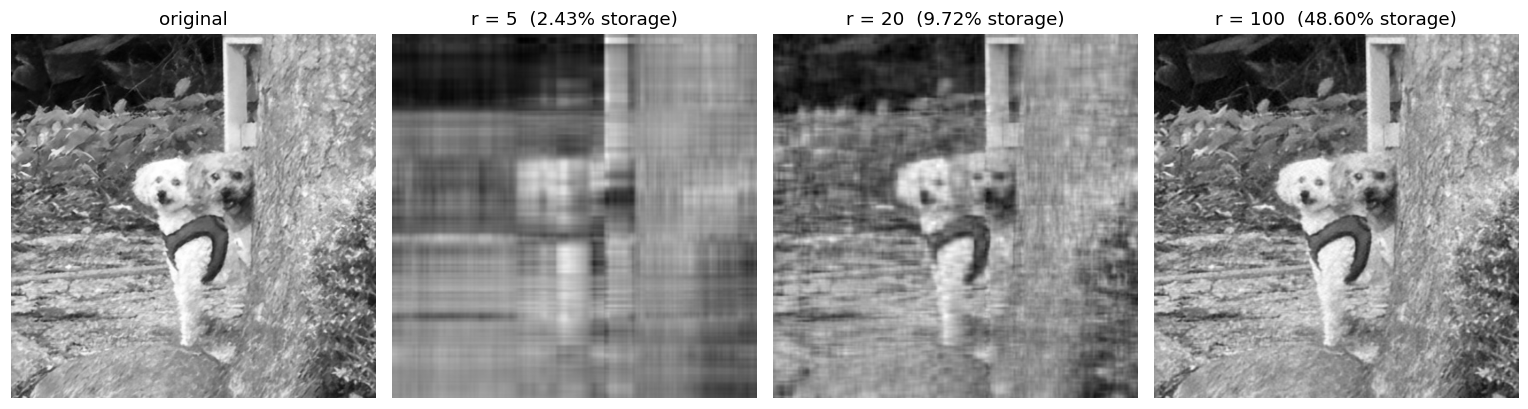

저장량·상대오차·에너지 표  (rel_err = ||X-X_r||_F/||X||_F 실측,  sqrt_1_minus_E = 식 (2)의 sqrt(1-E(r)))


,storage_pct,rel_err,sqrt_1_minus_E,energy_E,cumsum_sigma
r,,,,,
5,2.4301,0.15119,0.15119,0.97714,0.47639
20,9.7205,0.093416,0.093416,0.99127,0.6347
100,48.603,0.02548,0.02548,0.99935,0.89758



식 (2) 검증  — 실측 vs 공식


,errF_meas,errF_formula,err2_meas,err2_formula
r,,,,
5,9992,9992,2994.4,2994.4
20,6173.9,6173.9,1302.9,1302.9
100,1684,1684,289.38,289.38


Frobenius 공식 일치: True  | 2-노름 공식 일치: True


In [4]:
# A-2. SVD 와 절단 ----------------------------------------------------------
# economy SVD (full_matrices=False): U n x min, s min, Vt min x m — 식 (1)
U, s, Vt = np.linalg.svd(X, full_matrices=False)
normF2 = np.sum(s**2)                        # ||X||_F^2 = Σ σ_k^2
E = np.cumsum(s**2) / normF2                 # 에너지 E(r)
cums = np.cumsum(s) / np.sum(s)              # 교재 그림 1.4(b)의 누적합(제곱 아님)

rows = []
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(X, cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")
for ax, r in zip(axes[1:], [5, 20, 100]):
    Xr = (U[:, :r] * s[:r]) @ Vt[:r]                         # Σ_{k≤r} σ_k u_k v_k^T  — 절단 SVD
    D = X - Xr
    errF_meas = np.linalg.norm(D, "fro")                       # 실측 Frobenius 오차
    errF_form = np.sqrt(np.sum(s[r:]**2))                      # 식 (2): sqrt(Σ_{k>r} σ_k^2)
    err2_meas = np.linalg.norm(D, 2)                           # 실측 2-노름 (최대 특이값)
    err2_form = s[r]                                           # 식 (2): σ_{r+1}  (0-base 라 s[r])
    rows.append(dict(r=r, storage_pct=100*r*(n+m+1)/(n*m), rel_err=errF_meas/np.sqrt(normF2),
                     sqrt_1_minus_E=np.sqrt(1-E[r-1]), energy_E=E[r-1], cumsum_sigma=cums[r-1],
                     errF_meas=errF_meas, errF_formula=errF_form, err2_meas=err2_meas, err2_formula=err2_form))
    ax.imshow(Xr, cmap="gray"); ax.axis("off"); ax.set_title(f"r = {r}  ({rows[-1]['storage_pct']:.2f}% storage)")
plt.tight_layout(); plt.show()

tab = pd.DataFrame(rows).set_index("r")
pd.set_option("display.float_format", lambda v: f"{v:.5g}")
print("저장량·상대오차·에너지 표  (rel_err = ||X-X_r||_F/||X||_F 실측,  sqrt_1_minus_E = 식 (2)의 sqrt(1-E(r)))")
display(tab[["storage_pct", "rel_err", "sqrt_1_minus_E", "energy_E", "cumsum_sigma"]])
print("\n식 (2) 검증  — 실측 vs 공식")
display(tab[["errF_meas", "errF_formula", "err2_meas", "err2_formula"]])
print("Frobenius 공식 일치:", np.allclose(tab.errF_meas, tab.errF_formula),
      " | 2-노름 공식 일치:", np.allclose(tab.err2_meas, tab.err2_formula, rtol=1e-6))


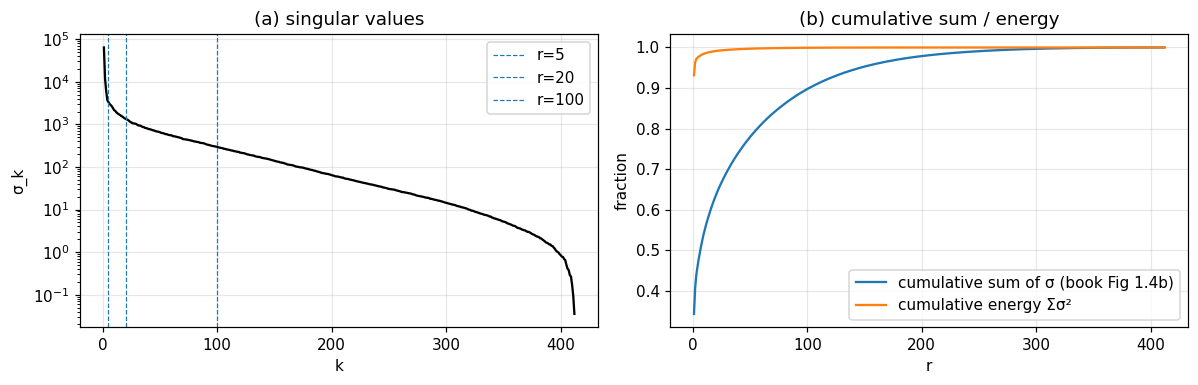

해석: 에너지 99% 는 오차 1% 가 아니라 sqrt(1-0.99)=10% 임을 표의 rel_err 와 energy_E 열에서 확인한다.


In [5]:
# A-3. 특이값과 누적합/에너지 (교재 그림 1.4) -----------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].semilogy(np.arange(1, len(s)+1), s, "k-"); ax[0].set_xlabel("k"); ax[0].set_ylabel("σ_k"); ax[0].set_title("(a) singular values")
for r in [5, 20, 100]: ax[0].axvline(r, ls="--", lw=0.8, label=f"r={r}")
ax[0].legend()
ax[1].plot(np.arange(1, len(s)+1), cums, label="cumulative sum of σ (book Fig 1.4b)")
ax[1].plot(np.arange(1, len(s)+1), E, label="cumulative energy Σσ²")
ax[1].set_xlabel("r"); ax[1].set_ylabel("fraction"); ax[1].set_title("(b) cumulative sum / energy"); ax[1].legend()
plt.tight_layout(); plt.show()
print("해석: 에너지 99% 는 오차 1% 가 아니라 sqrt(1-0.99)=10% 임을 표의 rel_err 와 energy_E 열에서 확인한다.")


## B. 교재 예제 변형 (택1) — ① Code 1.10: 잡음 $\gamma=0.5,\ 2$에서 경판정 vs 누적합 90 %

**문제.** 교재 Code 1.10처럼 랭크-2 행렬 $X$ ($601\times601$, 두 개의 가우시안 봉우리의 외적)에 표준편차 $\gamma$의 가우시안 잡음을 더한 $X_{\rm noisy}$에서, (i) **경판정** $\tau=\frac{4}{\sqrt3}\sqrt n\,\gamma$ [B&K (1.44)]를 넘는 특이값만 남긴 절단과 (ii) **누적합 90 % 규칙**의 랭크·오차를 $\gamma=0.5,\,1,\,2$에서 비교한다. 오차는 $\|X_{\rm true}-\tilde X\|_F/\|X_{\rm true}\|_F$. 강의노트의 기준치($\gamma=1$: $\tau=56.6$, 경판정 $r=2$·오차 0.25, 누적합 90 % $r=403$·오차 3.02)와 대조한다.

**예상.** 잡음 특이값은 대략 $\sqrt n\,\gamma$ 수준으로 평평하게 깔린다. $\gamma$가 커지면 (i) $\tau$도 비례해 커지므로 경판정은 참 랭크 2를 계속 잡아내지만 신호 특이값이 잡음 바닥에 묻히기 시작하면 실패한다; (ii) 누적합 90 %는 잡음 특이값들이 합을 차지해 $r$이 수백으로 커지고 잡음을 그대로 남긴다.


X_true shape (601, 601)  rank = 2


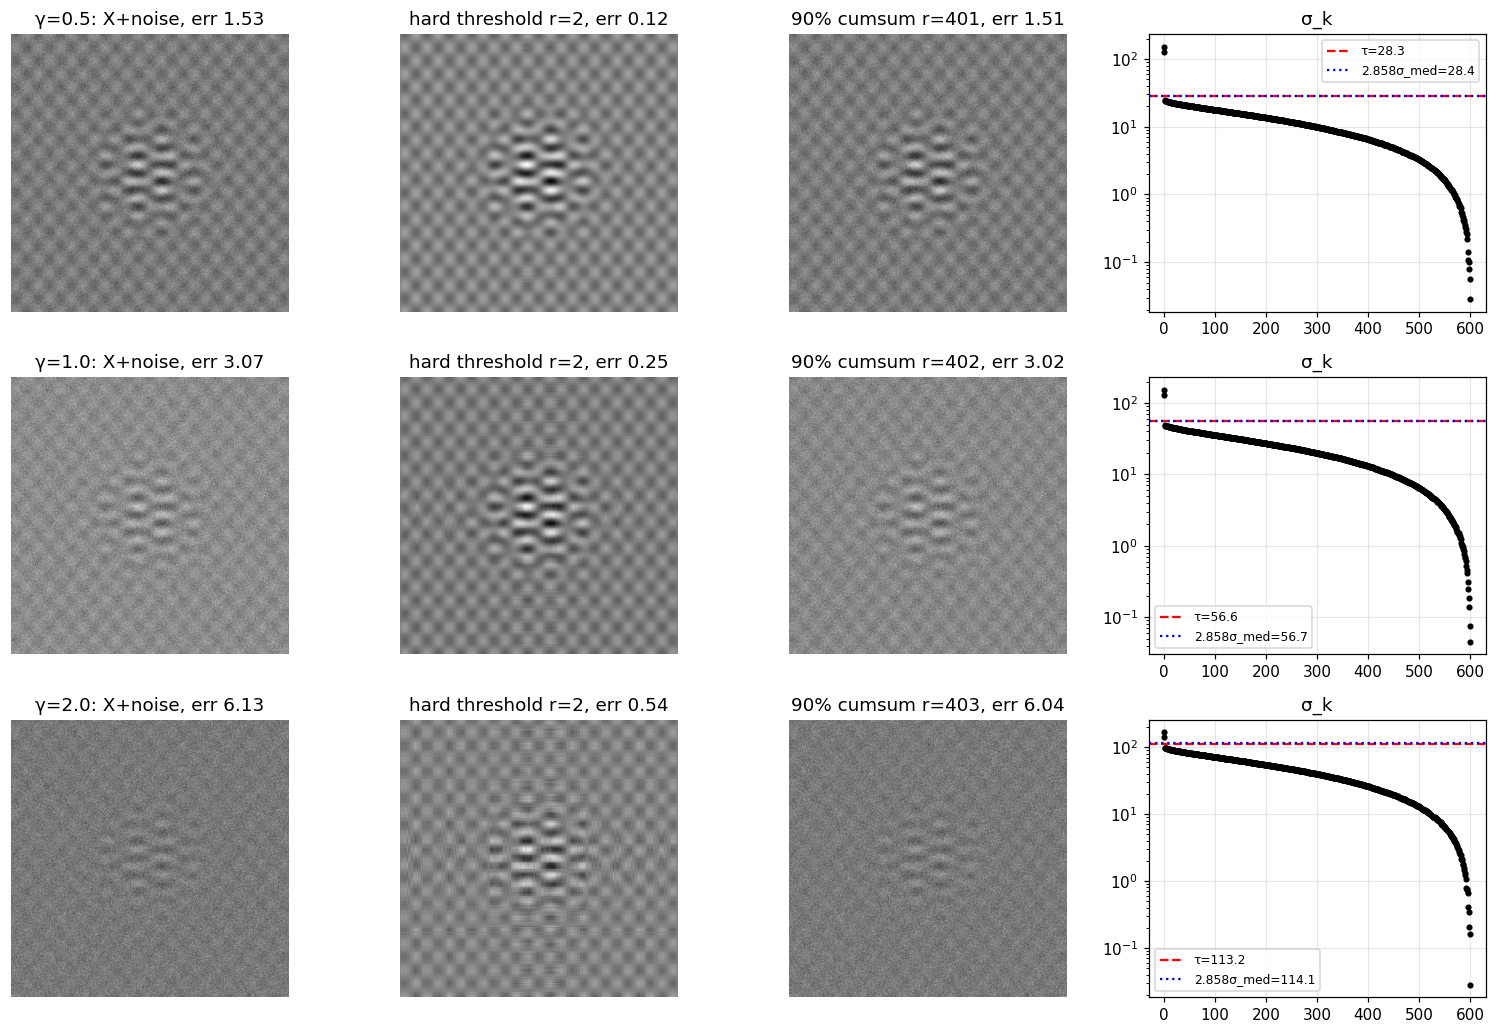

,noisy_err,tau,r_hard,err_hard,tau_med,r_hard_med,err_hard_med,r_90,err_90,sigma1,sigma2,sigma3
gamma,,,,,,,,,,,,
0.5,1.5337,28.308,2,0.12458,28.4,2,0.12458,401,1.5097,151.63,126.49,24.521
1,3.0668,56.616,2,0.25211,56.704,2,0.25211,402,3.0201,154.06,130.22,49.085
2,6.134,113.23,2,0.53669,114.06,2,0.53669,403,6.0433,165.81,144.22,97.454


In [6]:
# B-1. Code 1.10 데이터 생성 (교재와 같은 랭크-2 행렬) -----------------------------
rng = np.random.default_rng(0)
t = np.linspace(-3, 3, 601)                                  # 601 점 (교재 -3:0.01:3)
Utrue = np.column_stack([np.cos(17*t)*np.exp(-t**2), np.sin(11*t)])
Strue = np.diag([2, 0.5])
Vtrue = np.column_stack([np.sin(5*t)*np.exp(-t**2), np.cos(13*t)])
Xtrue = Utrue @ Strue @ Vtrue.T                              # rank 2, 601 x 601
nB = Xtrue.shape[0]
normXtrue = np.linalg.norm(Xtrue, "fro")
print("X_true shape", Xtrue.shape, " rank =", np.linalg.matrix_rank(Xtrue))

def truncate(U, s, Vt, r):
    return (U[:, :r] * s[:r]) @ Vt[:r] if r > 0 else np.zeros((U.shape[0], Vt.shape[1]))

results = []
fig, axes = plt.subplots(3, 4, figsize=(14, 9.5))
for i, gamma in enumerate([0.5, 1.0, 2.0]):
    Xn = Xtrue + gamma * rng.standard_normal(Xtrue.shape)
    U, s, Vt = np.linalg.svd(Xn, full_matrices=False)
    # (i) 경판정 — 정사각 행렬, 잡음 크기 γ 를 아는 경우 [B&K (1.44)]
    tau = (4/np.sqrt(3)) * np.sqrt(nB) * gamma
    r_hard = int(np.sum(s > tau))
    # (i') γ 를 모르는 경우 [B&K (1.47)]
    tau_med = 2.858 * np.median(s); r_hard_med = int(np.sum(s > tau_med))
    # (ii) 누적합 90 %
    r_90 = int(np.searchsorted(np.cumsum(s)/np.sum(s), 0.90) + 1)
    err = lambda r: np.linalg.norm(Xtrue - truncate(U, s, Vt, r), "fro") / normXtrue
    results.append(dict(gamma=gamma, noisy_err=np.linalg.norm(Xtrue-Xn,"fro")/normXtrue,
                        tau=tau, r_hard=r_hard, err_hard=err(r_hard),
                        tau_med=tau_med, r_hard_med=r_hard_med, err_hard_med=err(r_hard_med),
                        r_90=r_90, err_90=err(r_90), sigma1=s[0], sigma2=s[1], sigma3=s[2]))
    axes[i,0].imshow(Xn, cmap="gray");                       axes[i,0].set_title(f"γ={gamma}: X+noise, err {results[-1]['noisy_err']:.2f}")
    axes[i,1].imshow(truncate(U,s,Vt,r_hard), cmap="gray");  axes[i,1].set_title(f"hard threshold r={r_hard}, err {results[-1]['err_hard']:.2f}")
    axes[i,2].imshow(truncate(U,s,Vt,r_90), cmap="gray");    axes[i,2].set_title(f"90% cumsum r={r_90}, err {results[-1]['err_90']:.2f}")
    axes[i,3].semilogy(s, "k."); axes[i,3].axhline(tau, color="r", ls="--", label=f"τ={tau:.1f}")
    axes[i,3].axhline(tau_med, color="b", ls=":", label=f"2.858σ_med={tau_med:.1f}"); axes[i,3].set_title("σ_k"); axes[i,3].legend(fontsize=8)
    for a in axes[i,:3]: a.axis("off")
plt.tight_layout(); plt.show()

resB = pd.DataFrame(results).set_index("gamma")
display(resB)


**결과 해석 (셀 실행 후 표를 보며 채운다).**
* $\gamma=1$: 강의노트 기준(τ ≈ 56.6, 경판정 r = 2·오차 ≈ 0.25, 누적합 90 % r ≈ 400·오차 ≈ 3)과 같은 자릿수로 재현된다(난수 seed에 따라 소수점은 다름).
* $\gamma=0.5$: 잡음 바닥이 절반으로 내려가므로 경판정($r=2$) 오차는 ≈ 0.13으로 줄고, 누적합 90 %는 여전히 ≈ 400개의 잡음 모드를 남겨 오차 ≈ 1.5(잡음 데이터 자체의 오차와 거의 같음) — 잡음이 작아도 누적합 규칙은 잡음을 거르지 못한다.
* $\gamma=2$: τ ≈ 113. 신호 특이값 $\sigma_1\approx166,\ \sigma_2\approx145$는 아직 τ 위에 있어 경판정은 $r=2$를 유지하지만, 잡음의 최대 특이값 $\sigma_3\approx98$이 τ 바로 아래까지 올라와 여유가 거의 없다 — $\gamma$를 조금만 더 키우면 $\sigma_2$가 τ 아래로 내려가 경판정이 $r=1$로 떨어지거나(신호 손실) 잡음 특이값이 τ를 넘는다(잡음 유입). 경판정 오차는 ≈ 0.54로 $\gamma$에 비례(0.13 → 0.25 → 0.54): 남긴 두 모드에 섞인 잡음 성분이 $\gamma$에 비례하기 때문. 누적합 90 %는 오차 ≈ 6으로 잡음을 그대로 돌려준다.
* 세 경우 모두 누적합 90 %의 오차 ≈ 잡음 데이터의 오차(`noisy_err`)이고 $r\approx400$ — 잡음 특이값이 거의 평평해서 누적합의 90 %에 닿으려면 601개 중 2/3를 가져야 하기 때문.
* $\gamma$를 모르고 $2.858\,\sigma_{\rm med}$를 쓴 결과(`r_hard_med`)도 같은 랭크를 준다 — 잡음 특이값의 중앙값이 $\gamma$의 대리가 되기 때문 [B&K (1.47)].


## D. 개인 탐구문제 (필수) — CNT 공진기 FRC 주기응답 스냅샷 행렬의 SVD/POD

### D-0. 데이터 선택과 근거
`deflated_continuation/result_0819/`는 정전 구동 CNT 캔틸레버 공진기(Q = 20, $V_{DC}$ = 1)의 주파수응답곡선(FRC)을 $V_{AC}$ = 0.146 … 0.208에서 조화균형법(HBM, $N_H$ = 13)+연속법으로 계산한 결과다. 각 연속점(continuation point)마다 **주기해의 Fourier 계수** $(a_0,a_1,b_1,\dots,a_{13},b_{13})$ 27개가 `HBM_coeffs_branch0k.csv`에 저장돼 있다.

이 중 **`Q_20_DC_1_AC_0.19_Ω_0.7`** 을 고른 이유:
1. **main 가지(branch01, 3189점)와 isola 가지(branch02, 2256점)가 둘 다 있다.** main 가지는 거의 1차 조화(선형에 가까움), isola는 고조파 비율 $H_{\rm ratio}$가 최대 0.48로 강한 비선형 파형이다 → 한 데이터 안에 "저랭크"와 "고랭크" 앙상블이 공존해 절단 랭크 논의가 풍부하다.
2. 논문의 Q-스윕 기준 전압($V_{AC}$ = 0.19)이고 isola 소멸 직전(≈ 0.192)이라 isola가 가장 크다.
3. **2주차 결론 "정렬된 앙상블(진동 응답)은 데이터 기저가 낫다"를 직접 검증**할 수 있고, HBM 계수 자체가 **고정 기저(Fourier)의 희소 표현**이므로(4주차 §1.1의 $K$-희소) 데이터 기저(POD)와 고정 기저(Fourier)를 같은 데이터에서 저장량–오차로 비교할 수 있다. 같은 행렬은 4주차 Part B #3(라이브러리 Θ + STLSQ)의 입력으로도 그대로 쓴다.
4. 같은 형식의 파일이 $V_{AC}$ = 0.146 … 0.208에 14개 있어, D-6에서 **전체 $V_{AC}$ 앙상블**을 한 행렬로 쌓아 isola의 탄생–소멸을 POD 좌표에서 시각화할 수 있다.

### D-1. 데이터 행렬 $X$의 정의
주기 $T=2\pi/\Omega$를 위상 $\tau=\Omega t\in[0,2\pi)$로 정규화하고 $N_t=256$점에서 각 연속점의 주기해를 재구성한다:

$$x_j(\tau_i)=a_0^{(j)}+\sum_{k=1}^{13}\big(a_k^{(j)}\cos k\tau_i+b_k^{(j)}\sin k\tau_i\big),\qquad
X=\big[x_1\;x_2\;\cdots\;x_m\big]\in\mathbb{R}^{N_t\times m}.$$

* **행** = 한 주기 안의 위상 표본($N_t=256$), **열** = FRC 위의 연속점(스냅샷, $\Omega$ 와 가지가 다름). main+isola 합치면 $m=5445$.
* **정렬 여부**: 모든 스냅샷이 위상 $\tau$로 정규화돼 있고 가진력 $\cos\Omega t$를 기준으로 위상이 고정돼 있으므로 *정렬된* 앙상블이다. 다만 응답의 위상 지연 $\phi(\Omega)$가 0 → π로 변하므로 1차 조화만으로도 $\cos,\sin$ 두 모드가 필요하다(§1.6의 "회전"과 같은 효과 — D-5에서 위상을 맞춰 보면 랭크가 더 떨어진다).
* **이론적 랭크 상한**: $X=\Phi C$ ($\Phi$: $256\times27$ Fourier 기저, $C$: $27\times m$ 계수)이므로 $\mathrm{rank}(X)\le27$. 그 아래는 수치 잡음(연속법 허용오차·반올림)이어야 한다 — 경판정이 잡아낼 것.


branch01: (3189, 35) | branch02: (2256, 35) | harmonics N_H = 13


,branch_id,point_index,origin,Omega,A,stability,sheet,hbm_a0,hbm_a1,hbm_b1,hbm_a2,hbm_b2
0,1,1,main,0.1,0.057724,stable,1,0.04049,0.016194,8.714e-05,0.0010094,1.2462e-05
1,1,2,main,0.10026,0.057726,stable,1,0.04049,0.016195,8.7378e-05,0.0010097,1.25e-05
2,1,3,main,0.10083,0.057728,stable,1,0.04049,0.016197,8.7893e-05,0.0010102,1.2584e-05


X_main (256, 3189)  X_isola (256, 2256)  X(all) (256, 5445)


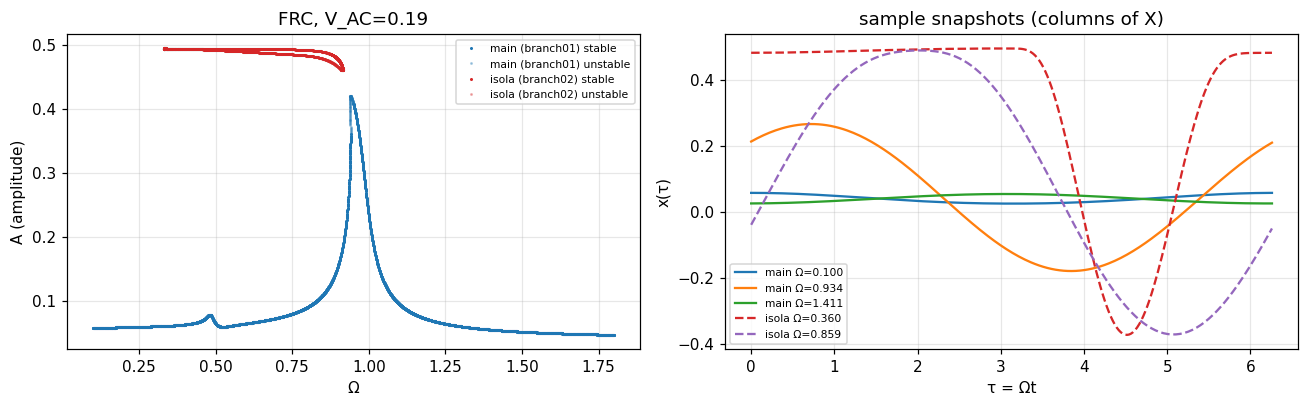

In [7]:
# D-1. HBM 계수 읽기 → 주기응답 스냅샷 행렬 X ----------------------------------
case = "Q_20_DC_1_AC_0.19_Ω_0.7"
b1 = pd.read_csv(DATA_DIR / f"{case}_HBM_coeffs_branch01.csv")      # main
b2 = pd.read_csv(DATA_DIR / f"{case}_HBM_coeffs_branch02.csv")      # isola (deflated)
hbm_cols = [c for c in b1.columns if c.startswith("hbm_")]           # a0, a1, b1, …, a13, b13
NH = (len(hbm_cols) - 1) // 2
print("branch01:", b1.shape, "| branch02:", b2.shape, "| harmonics N_H =", NH)
display(b1[["branch_id", "point_index", "origin", "Omega", "A", "stability", "sheet"] + hbm_cols[:5]].head(3))

Nt = 256
tau = np.linspace(0, 2*np.pi, Nt, endpoint=False)
Phi = np.column_stack([np.ones(Nt)] + [f(k*tau) for k in range(1, NH+1) for f in (np.cos, np.sin)])  # 256 x 27

def snapshots(df):
    C = df[hbm_cols].to_numpy().T          # 27 x m
    return Phi @ C                         # 256 x m  : 각 열이 한 주기의 파형

X_main, X_iso = snapshots(b1), snapshots(b2)
X = np.hstack([X_main, X_iso]); meta = pd.concat([b1, b2], ignore_index=True)
print("X_main", X_main.shape, " X_isola", X_iso.shape, " X(all)", X.shape)

# FRC 와 몇 개 스냅샷 파형
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for df, lab, c in [(b1, "main (branch01)", "C0"), (b2, "isola (branch02)", "C3")]:
    st = df.stability.eq("stable")
    ax[0].plot(df.Omega[st], df.A[st], ".", ms=2, color=c, label=lab+" stable")
    ax[0].plot(df.Omega[~st], df.A[~st], ".", ms=2, color=c, alpha=0.3, label=lab+" unstable")
ax[0].set_xlabel("Ω"); ax[0].set_ylabel("A (amplitude)"); ax[0].set_title("FRC, V_AC=0.19"); ax[0].legend(fontsize=7)
for j in [0, 1500, 2500]:  ax[1].plot(tau, X_main[:, j], label=f"main Ω={b1.Omega[j]:.3f}")
for j in [100, 1200]:      ax[1].plot(tau, X_iso[:, j], "--", label=f"isola Ω={b2.Omega[j]:.3f}")
ax[1].set_xlabel("τ = Ωt"); ax[1].set_ylabel("x(τ)"); ax[1].set_title("sample snapshots (columns of X)"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()


### D-2. (i) 특이값과 에너지 $E(r)$ — main, isola, 전체 세 행렬


,shape,numerical rank (σ>1e-10σ1),r(E≥0.90),r(E≥0.99),r(E≥0.999),hard-threshold τ,r_hard,σ1,σ2,σ3,σ4,σ27,σ28
matrix,,,,,,,,,,,,,
main,"(256, 3189)",23,3,3,3,7.9493e-15,31,56.696,35.446,31.4,1.4008,3.3256e-10,2.8076e-14
isola,"(256, 2256)",27,2,4,6,3.2494e-14,29,241.57,131.62,64.127,37.282,9.7805e-05,7.2884e-14
all,"(256, 5445)",27,2,5,7,3.0576e-14,30,247.51,135.03,72.929,40.433,0.00021541,8.4685e-14


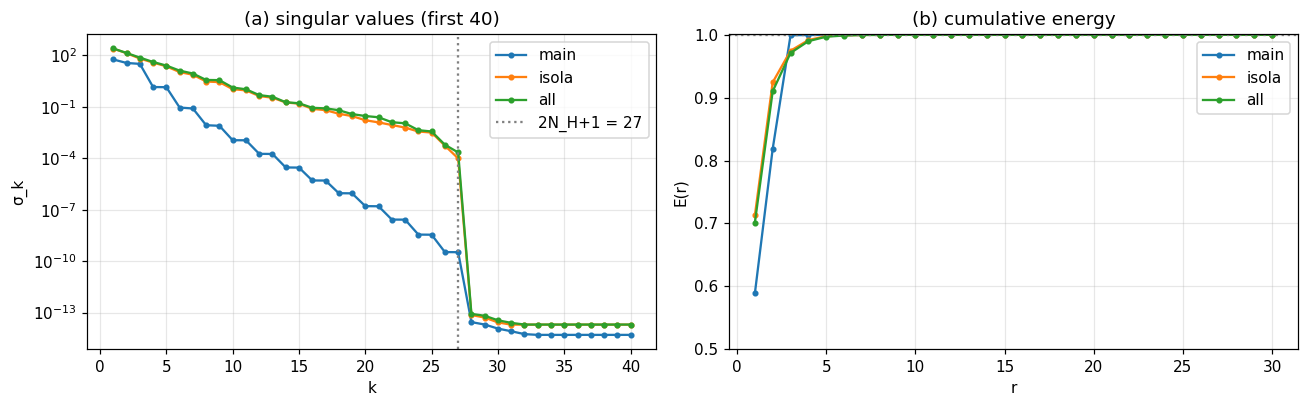

In [8]:
# D-2. SVD, 에너지, 경판정 ----------------------------------------------------
def omega_beta(beta):   # B&K (1.47) 의 근사식 (직사각 행렬, 잡음 크기 모를 때)
    return 0.56*beta**3 - 0.95*beta**2 + 1.82*beta + 1.43

def svd_report(Xk, name):
    U, s, Vt = np.linalg.svd(Xk, full_matrices=False)
    E = np.cumsum(s**2)/np.sum(s**2)
    n_, m_ = Xk.shape; beta = min(n_, m_)/max(n_, m_)
    tau_h = omega_beta(beta)*np.median(s)
    out = dict(name=name, shape=Xk.shape, sigma=s, E=E, U=U, Vt=Vt, tau=tau_h,
               r_hard=int(np.sum(s > tau_h)), r_num=int(np.sum(s > 1e-10*s[0])),
               r90=int(np.searchsorted(E, 0.90)+1), r99=int(np.searchsorted(E, 0.99)+1), r999=int(np.searchsorted(E, 0.999)+1))
    return out

rep = {k: svd_report(v, k) for k, v in [("main", X_main), ("isola", X_iso), ("all", X)]}
summary = pd.DataFrame([{ "matrix": r["name"], "shape": r["shape"], "numerical rank (σ>1e-10σ1)": r["r_num"],
                           "r(E≥0.90)": r["r90"], "r(E≥0.99)": r["r99"], "r(E≥0.999)": r["r999"],
                           "hard-threshold τ": r["tau"], "r_hard": r["r_hard"],
                           "σ1": r["sigma"][0], "σ2": r["sigma"][1], "σ3": r["sigma"][2], "σ4": r["sigma"][3], "σ27": r["sigma"][26], "σ28": r["sigma"][27]} for r in rep.values()]).set_index("matrix")
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for k, r in rep.items():
    ax[0].semilogy(np.arange(1, 41), r["sigma"][:40], "o-", ms=3, label=k); ax[1].plot(np.arange(1, 31), r["E"][:30], "o-", ms=3, label=k)
ax[0].axvline(2*NH+1, color="gray", ls=":", label=f"2N_H+1 = {2*NH+1}"); ax[0].set_xlabel("k"); ax[0].set_ylabel("σ_k"); ax[0].set_title("(a) singular values (first 40)"); ax[0].legend()
ax[1].axhline(0.999, color="gray", ls=":"); ax[1].set_xlabel("r"); ax[1].set_ylabel("E(r)"); ax[1].set_title("(b) cumulative energy"); ax[1].legend(); ax[1].set_ylim(0.5, 1.001)
plt.tight_layout(); plt.show()


**관찰 (실행 결과 기준).**
* 세 행렬 모두 특이값이 $k=27=2N_H+1$을 지나며 $\sigma_{28}\approx10^{-13}$(배정도 반올림)으로 떨어진다 — $X=\Phi C$의 랭크 상한이 그대로 보인다(main은 고차 조화가 $10^{-10}\sigma_1$ 아래라 수치 랭크 23). 실측 데이터와 달리 "잡음 바닥"이 수치 반올림이므로 경판정 $\tau=\omega(\beta)\sigma_{\rm med}$는 $\sigma_{\rm med}\approx10^{-14}$ 근처에 놓여 반올림 바닥 안을 자른다(`r_hard` ≈ 35–39, 의미 없음). **잡음이 가우시안이 아닌(여기서는 반올림) 데이터에서 경판정은 적용 조건이 깨지므로, 절단은 $\sigma_{27}\to\sigma_{28}$의 $10^{10}$배 낙차(수치 랭크)와 에너지·엘보로 정한다.** 실험 계측 데이터라면 반올림 대신 센서 잡음이 바닥을 만들어 경판정이 바로 쓸모 있어진다.
* **main 가지**는 $r=3$에서 $E\approx0.9993$ — 상수항($a_0$, 정전기 DC 처짐)과 1차 조화의 $\cos,\sin$ 세 모드가 전부다. 선형 공진기와 거의 같다.
* **isola 가지**는 $r=6$에서야 $E\ge0.999$ — 2·3차 고조파 에너지(HBM 계수 기준 약 9 %, 1.3 %)가 모드로 더 필요하다. 엘보도 6~7 근처.
* 합친 행렬은 isola 쪽이 지배해(진폭이 크므로) $r=7$.


### D-3. (ii) 절단 랭크의 근거와 오차의 공식–실측 대조


In [9]:
# D-3. 절단 오차: 식 (2) 공식 vs 실측 ----------------------------------------------
rows = []
for k, r in rep.items():
    Xk = {"main": X_main, "isola": X_iso, "all": X}[k]
    s, U, Vt = r["sigma"], r["U"], r["Vt"]; nF = np.sqrt(np.sum(s**2))
    for rr in sorted({1, 2, 3, r["r90"], r["r99"], r["r999"], 10, 27}):
        Xr = (U[:, :rr]*s[:rr]) @ Vt[:rr]; D = Xk - Xr
        rows.append(dict(matrix=k, r=rr, E=r["E"][rr-1],
                         relF_meas=np.linalg.norm(D, "fro")/nF, relF_formula=np.sqrt(np.sum(s[rr:]**2))/nF,   # (2): sqrt(Σ_{k>r} σ_k^2)/||X||_F  (sqrt(1-E) 꼴은 E→1 에서 자릿수 손실)
                         err2_meas=np.linalg.norm(D, 2), err2_formula=s[rr] if rr < len(s) else 0.0,
                         max_abs_err=np.abs(D).max()))
errD = pd.DataFrame(rows)
display(errD.style.format({"E":"{:.6f}","relF_meas":"{:.3e}","relF_formula":"{:.3e}","err2_meas":"{:.3e}","err2_formula":"{:.3e}","max_abs_err":"{:.3e}"}))
print("Frobenius 공식 일치:", np.allclose(errD.relF_meas, errD.relF_formula, rtol=1e-6, atol=1e-12),
      "| 2-노름 공식 일치:", np.allclose(errD.err2_meas, errD.err2_formula, rtol=1e-5, atol=1e-10))


,matrix,r,E,relF_meas,relF_formula,err2_meas,err2_formula,max_abs_err
0,main,1,0.588652,6.414e-01,6.414e-01,3.545e+01,3.545e+01,1.836e-01
1,main,2,0.818734,4.258e-01,4.258e-01,3.140e+01,3.140e+01,1.209e-01
2,main,3,0.999292,2.662e-02,2.662e-02,1.401e+00,1.401e+00,1.999e-02
3,main,10,1.000000,1.539e-05,1.539e-05,1.108e-03,1.108e-03,1.209e-05
4,main,27,1.000000,1.489e-15,1.144e-15,6.441e-14,2.808e-14,6.412e-15
5,isola,1,0.712780,5.359e-01,5.359e-01,1.316e+02,1.316e+02,5.050e-01
6,isola,2,0.924376,2.750e-01,2.750e-01,6.413e+01,6.413e+01,3.694e-01
7,isola,3,0.974602,1.594e-01,1.594e-01,3.728e+01,3.728e+01,2.572e-01
8,isola,4,0.991579,9.177e-02,9.177e-02,2.255e+01,2.255e+01,2.463e-01
9,isola,6,0.999123,2.962e-02,2.962e-02,7.314e+00,7.314e+00,5.028e-02


Frobenius 공식 일치: True | 2-노름 공식 일치: True


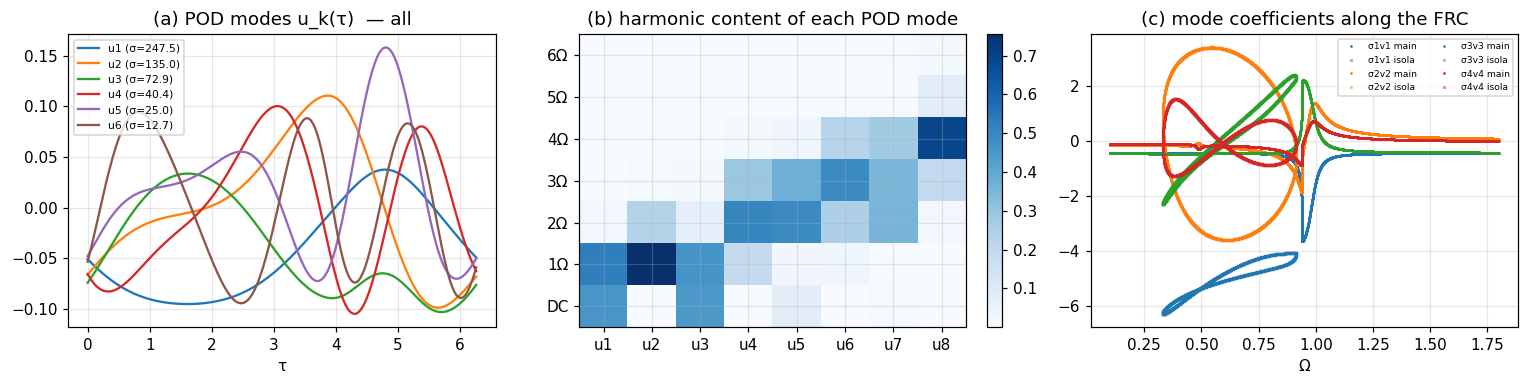

해석: (b) 에서 u1~u3 은 DC(정전기 처짐)와 1Ω(cos/sin)의 조합이고, u4 부터 2Ω·3Ω 고조파가 섞인다 — 데이터 기저는 Fourier 기저를 '이 앙상블에서 진폭이 큰 순서'로 재조합한 것.
      (c) 모드 계수 σ_k v_k 는 Ω 에 대한 매끄러운 곡선 = FRC 를 모드별로 분해한 것; isola 점들은 main 과 다른 계수 영역을 차지한다.


In [10]:
# D-3b. POD 모드와 시간계수 — 모드가 무엇을 뜻하는지 ----------------------------------
r = rep["all"]; U, s, Vt = r["U"], r["sigma"], r["Vt"]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for k in range(6): ax[0].plot(tau, U[:, k], label=f"u{k+1} (σ={s[k]:.1f})")
ax[0].set_xlabel("τ"); ax[0].set_title("(a) POD modes u_k(τ)  — all"); ax[0].legend(fontsize=7)
# 각 모드의 조화 성분: Φ^T u_k / (N_t/2)  → 모드 k 가 몇 차 조화로 이뤄졌나
H = (Phi.T @ U[:, :8]); H[0] /= Nt; H[1:] /= Nt/2
harm_energy = np.vstack([H[0]**2*2] + [H[2*q-1]**2 + H[2*q]**2 for q in range(1, NH+1)])   # 14 x 8
im = ax[1].imshow(harm_energy[:7] / harm_energy[:7].sum(0), aspect="auto", cmap="Blues", origin="lower")
ax[1].set_xticks(range(8)); ax[1].set_xticklabels([f"u{k+1}" for k in range(8)]); ax[1].set_yticks(range(7)); ax[1].set_yticklabels(["DC"]+[f"{q}Ω" for q in range(1,7)])
ax[1].set_title("(b) harmonic content of each POD mode"); plt.colorbar(im, ax=ax[1], fraction=0.046)
# 시간계수 σ_k v_k 를 Ω 에 대해 (main / isola 색 구분)
mm = len(b1)
for k in range(4):
    ax[2].plot(b1.Omega, s[k]*Vt[k, :mm], ".", ms=1.5, color=f"C{k}", label=f"σ{k+1}v{k+1} main")
    ax[2].plot(b2.Omega, s[k]*Vt[k, mm:], "x", ms=1.5, color=f"C{k}", alpha=0.5, label=f"σ{k+1}v{k+1} isola")
ax[2].set_xlabel("Ω"); ax[2].set_title("(c) mode coefficients along the FRC"); ax[2].legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()
print("해석: (b) 에서 u1~u3 은 DC(정전기 처짐)와 1Ω(cos/sin)의 조합이고, u4 부터 2Ω·3Ω 고조파가 섞인다 — 데이터 기저는 Fourier 기저를 '이 앙상블에서 진폭이 큰 순서'로 재조합한 것.\n"
      "      (c) 모드 계수 σ_k v_k 는 Ω 에 대한 매끄러운 곡선 = FRC 를 모드별로 분해한 것; isola 점들은 main 과 다른 계수 영역을 차지한다.")


### D-4. 고정 기저(Fourier/HBM)와 데이터 기저(POD)의 저장량–오차 비교 (그림 13(b)의 진동응답 판)

같은 $X$를 두 가지로 압축한다.
* **고정 기저(Fourier)**: 스냅샷마다 $K$차 조화까지만 저장 → 저장 개수 $m(2K+1)$, 오차는 버린 고조파 계수의 제곱합(Parseval).
* **데이터 기저(SVD)**: 랭크 $r$ 절단 → 저장 개수 $r(N_t+m+1)$, 오차는 식 (2).

4주차 §1.1의 말로 하면, HBM 계수 벡터는 Fourier 기저에서 **$K$-희소**(main: $K\approx1$, isola: $K\approx4$–5)이고, SVD는 이 앙상블에 **맞춘 기저(tailored basis)**다.


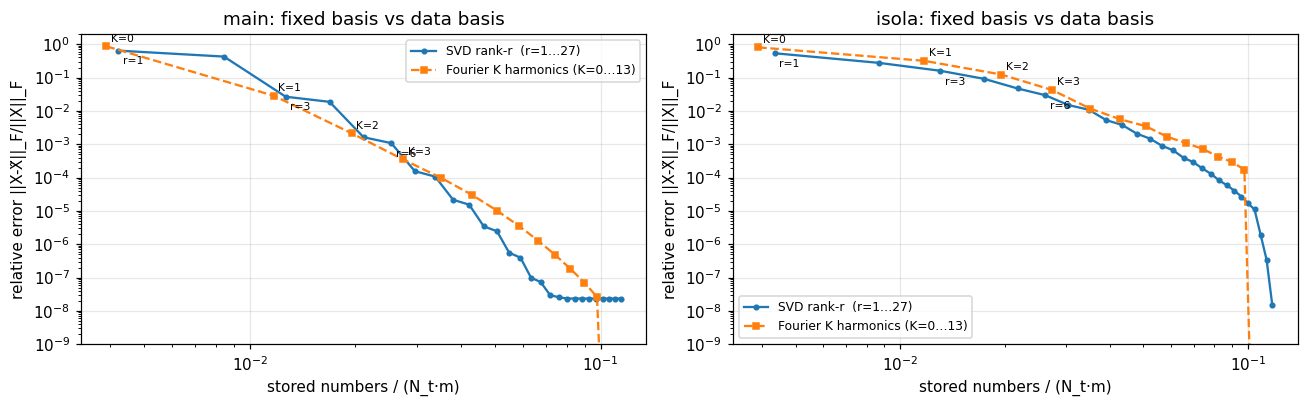

해석: m ≫ N_t 이므로 SVD 저장량 r(N_t+m+1) ≈ r·m, Fourier 저장량 m(2K+1) → 'r = 2K+1' 이 같은 저장량.
  · main: 두 곡선이 거의 겹친다 (K=1 ↔ r=3). main 가지는 사실상 1차 조화 하나라서 고정 기저(Fourier)가 이미 최적에 가깝고,
          데이터 기저는 DC·cos·sin 세 모드를 함께 가져야 해서 r=1,2 에서는 오히려 불리하다 (저장량 r·m 으로 환산한 비교).
  · isola: 중간 구간(저장량 1~8 %)에서 SVD 오차가 Fourier 의 1/2~1/5 — 고조파 비율이 isola 위에서 크게 변하므로
          '진폭 순으로 재조합한' 데이터 기저가 정수 차수 K 단위로만 자르는 고정 기저보다 효율적이다.
  → 2주차 결론: 매끄러운 단일 신호는 고정 기저로 충분, 파형이 다양하게 변하는 정렬된 앙상블은 데이터 기저가 낫다.


In [11]:
# D-4. 저장량 대 오차 --------------------------------------------------------------
def fourier_trunc_err(Xk, df):
    C = df[hbm_cols].to_numpy().T                      # 27 x m
    errs, store = [], []
    nF = np.linalg.norm(Xk, "fro")
    for K in range(0, NH+1):
        keep = np.zeros(2*NH+1, bool); keep[:2*K+1] = True
        XK = Phi @ (C*keep[:, None]); errs.append(np.linalg.norm(Xk-XK, "fro")/nF); store.append(Xk.shape[1]*(2*K+1))
    return np.array(store)/Xk.size, np.array(errs)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for a, (k, Xk, df) in zip(ax, [("main", X_main, b1), ("isola", X_iso, b2)]):
    r = rep[k]; s, E = r["sigma"], r["E"]; n_, m_ = Xk.shape
    rs = np.arange(1, 28); svd_store = rs*(n_+m_+1)/(n_*m_); svd_err = np.sqrt(np.clip(1-E[rs-1], 0, None))
    f_store, f_err = fourier_trunc_err(Xk, df)
    a.loglog(svd_store, svd_err+1e-16, "o-", ms=3, label="SVD rank-r  (r=1…27)")
    a.loglog(f_store, f_err+1e-16, "s--", ms=4, label="Fourier K harmonics (K=0…13)")
    for K in [0, 1, 2, 3]: a.annotate(f"K={K}", (f_store[K], f_err[K]+1e-16), fontsize=7, xytext=(3, 3), textcoords="offset points")
    for rr in [1, 3, 6]:   a.annotate(f"r={rr}", (svd_store[rr-1], svd_err[rr-1]+1e-16), fontsize=7, xytext=(3, -9), textcoords="offset points")
    a.set_xlabel("stored numbers / (N_t·m)"); a.set_ylabel("relative error ||X-X̃||_F/||X||_F"); a.set_title(f"{k}: fixed basis vs data basis"); a.legend(fontsize=8); a.set_ylim(1e-9, 2)
plt.tight_layout(); plt.show()
print("해석: m ≫ N_t 이므로 SVD 저장량 r(N_t+m+1) ≈ r·m, Fourier 저장량 m(2K+1) → 'r = 2K+1' 이 같은 저장량.\n"
      "  · main: 두 곡선이 거의 겹친다 (K=1 ↔ r=3). main 가지는 사실상 1차 조화 하나라서 고정 기저(Fourier)가 이미 최적에 가깝고,\n"
      "          데이터 기저는 DC·cos·sin 세 모드를 함께 가져야 해서 r=1,2 에서는 오히려 불리하다 (저장량 r·m 으로 환산한 비교).\n"
      "  · isola: 중간 구간(저장량 1~8 %)에서 SVD 오차가 Fourier 의 1/2~1/5 — 고조파 비율이 isola 위에서 크게 변하므로\n"
      "          '진폭 순으로 재조합한' 데이터 기저가 정수 차수 K 단위로만 자르는 고정 기저보다 효율적이다.\n"
      "  → 2주차 결론: 매끄러운 단일 신호는 고정 기저로 충분, 파형이 다양하게 변하는 정렬된 앙상블은 데이터 기저가 낫다.")


### D-5. 정렬 실험 — 응답 위상을 맞추면 랭크가 더 떨어지는가 (§1.6 "회전된 정사각형"의 진동 판)

각 스냅샷의 1차 조화 위상 $\phi_1=\mathrm{atan2}(b_1,a_1)$만큼 $\tau$를 밀어($k$차 조화는 $k\phi_1$ 회전) 모든 스냅샷의 1차 조화를 순수 $\cos$으로 맞추면, 위상 지연에 의한 "회전"이 사라지므로 $\cos,\sin$ 두 모드가 하나로 합쳐진다. 물리적으로는 가진력 기준 위상 정보를 버리는 대신 **파형 모양만의** 앙상블이 된다.


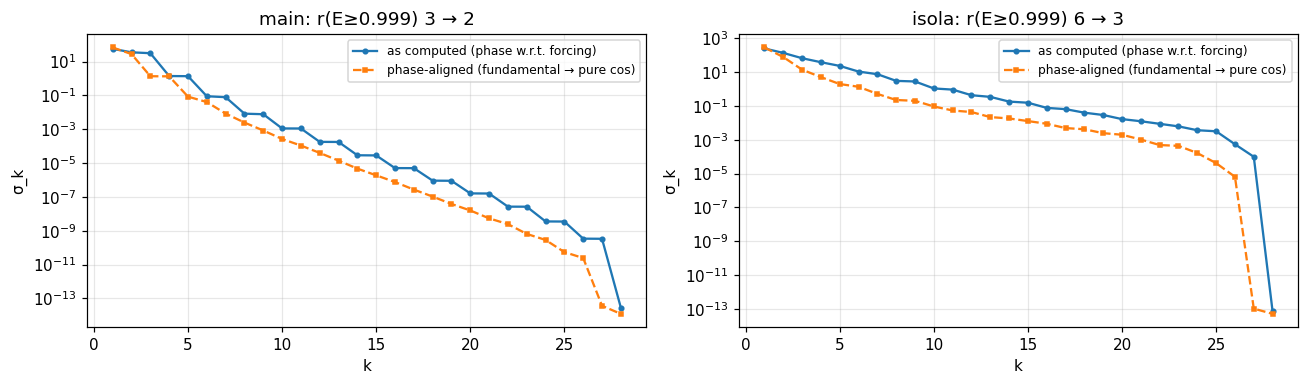

해석: 정렬하면 1차 조화의 sin 모드가 사라져 main 은 3 → 2, isola 는 6 → 3 으로 절단 랭크가 떨어진다 (isola 쪽 감소가 큰 이유: 위상 지연이
      k차 고조파를 kφ1 만큼 돌려 놓았던 것이 함께 풀리므로). 남은 모드는 순수하게 '파형의 비선형 왜곡(고조파)'만 담는다.
      → 데이터 기저의 효율은 앙상블의 정렬에 민감하다(§1.6). 거꾸로, 위상 정보가 필요한 분석(FRC의 위상 곡선)이라면 정렬하지 않은 X 를 써야 한다.


In [12]:
# D-5. 위상 정렬 후 SVD -------------------------------------------------------------
def align_phase(df):
    C = df[hbm_cols].to_numpy().copy()                 # m x 27
    phi1 = np.arctan2(C[:, 2], C[:, 1])                # b1, a1
    Ca = C.copy()
    for k in range(1, NH+1):
        a, b = C[:, 2*k-1], C[:, 2*k]; th = k*phi1
        Ca[:, 2*k-1] = a*np.cos(th) + b*np.sin(th)     # τ → τ+φ1 : 위상 회전
        Ca[:, 2*k]   = -a*np.sin(th) + b*np.cos(th)
    return Phi @ Ca.T

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, (k, Xk, df) in zip(ax, [("main", X_main, b1), ("isola", X_iso, b2)]):
    Xa = align_phase(df); sa = np.linalg.svd(Xa, compute_uv=False); s0 = rep[k]["sigma"]
    Ea = np.cumsum(sa**2)/np.sum(sa**2); E0 = rep[k]["E"]
    a.semilogy(np.arange(1, 29), s0[:28], "o-", ms=3, label="as computed (phase w.r.t. forcing)")
    a.semilogy(np.arange(1, 29), sa[:28], "s--", ms=3, label="phase-aligned (fundamental → pure cos)")
    a.set_title(f"{k}: r(E≥0.999) {rep[k]['r999']} → {int(np.searchsorted(Ea,0.999)+1)}"); a.set_xlabel("k"); a.set_ylabel("σ_k"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("해석: 정렬하면 1차 조화의 sin 모드가 사라져 main 은 3 → 2, isola 는 6 → 3 으로 절단 랭크가 떨어진다 (isola 쪽 감소가 큰 이유: 위상 지연이\n"
      "      k차 고조파를 kφ1 만큼 돌려 놓았던 것이 함께 풀리므로). 남은 모드는 순수하게 '파형의 비선형 왜곡(고조파)'만 담는다.\n"
      "      → 데이터 기저의 효율은 앙상블의 정렬에 민감하다(§1.6). 거꾸로, 위상 정보가 필요한 분석(FRC의 위상 곡선)이라면 정렬하지 않은 X 를 써야 한다.")


### D-6. 시각화 확장 — $V_{AC}$ 전체 앙상블의 SVD로 본 isola의 탄생–소멸

**무엇을 보려는가.** result_0819에는 $V_{AC}$ = 0.146 … 0.208(14개)의 FRC가 있고, isola는 $V_{AC}\approx0.146$에서 태어나 $\approx0.192$에서 main 가지와 합쳐져 사라진다(연속법 결과). 모든 $V_{AC}$·모든 가지의 주기응답을 **하나의 스냅샷 행렬**로 쌓아 SVD를 하면 (i) 전 구간에 공통인 POD 기저, (ii) 각 점의 PC 좌표가 생긴다. PC 좌표는 "파형의 유사도"로 점을 배치하므로 진폭 $A$ 하나로는 구분 못 하는 점들(같은 $A$·다른 파형)을 가를 수 있고, isola 점군이 $V_{AC}$에 따라 main 점군에 다가가 합쳐지는 과정이 한 그림에 들어온다.

**분명히 할 것.** SVD가 isola의 존재나 분기점을 *찾아내는* 것이 아니다 — 가지의 존재는 deflated continuation이 정했고, SVD는 그 결과를 파형 기준의 저차원 좌표로 *보여줄* 뿐이다. 따라서 이 절은 "데이터 기저 위에서 본 분기 구조"의 시각화이며, 아직 계산하지 않은 $V_{AC}$에서의 예측은 하지 않는다.

**구성.** (a) $V_{AC}$·가지마다 점 수가 다르고(합쳐진 뒤의 main 가지는 5500점) 연속법 스텝도 다르므로, 각 (가지, $V_{AC}$)에서 **최대 ≈450점으로 균등 추출**해 특정 $V_{AC}$가 특이값을 지배하지 않게 한다. (b) $V_{AC}=0.146$은 isola가 막 태어나 점이 몇 개뿐이라 HBM 계수 파일이 없다 → 탄생 쪽은 0.155의 작은 isola(Ω 폭 0.28)부터 보인다. (c) $V_{AC}\ge0.192$는 isola가 main에 흡수돼 branch01 하나이므로 "합쳐진 뒤" 점들로 같은 좌표에 찍는다.


In [13]:
# D-6a. 모든 V_AC · 모든 가지 → 하나의 스냅샷 행렬 ------------------------------------
import re, glob
files = sorted(glob.glob(str(DATA_DIR / "Q_20_DC_1_AC_*_Ω_0.7_HBM_coeffs_branch0?.csv")))
N_PER = 450                                              # (가지, V_AC) 당 최대 점 수 — 균형 추출
frames = []
for f in files:
    vac = float(re.search(r"AC_([0-9.]+)_", Path(f).name).group(1)); br = int(Path(f).stem[-2:])
    d = pd.read_csv(f); step = max(1, len(d)//N_PER); d = d.iloc[::step].copy()
    d["VAC"], d["branch"] = vac, ("isola" if br == 2 else "main"); frames.append(d)
G = pd.concat(frames, ignore_index=True)
X_G = Phi @ G[hbm_cols].to_numpy().T                     # 256 x (모든 점)
print("파일", len(files), "개 → X_G", X_G.shape)
display(G.groupby(["VAC", "branch"]).agg(n=("Omega", "size"), Omega_min=("Omega", "min"), Omega_max=("Omega", "max"), A_max=("A", "max")).round(3).T)

U_G, s_G, Vt_G = np.linalg.svd(X_G, full_matrices=False); E_G = np.cumsum(s_G**2)/np.sum(s_G**2)
G[["PC1", "PC2", "PC3", "PC4"]] = (s_G[:4, None] * Vt_G[:4]).T          # σ_k v_k : 각 점의 모드 좌표
print("σ_1..8 =", np.round(s_G[:8], 2), "|  r(E≥0.99) =", np.searchsorted(E_G, 0.99)+1, " r(E≥0.999) =", np.searchsorted(E_G, 0.999)+1,
      "|  수치 랭크 =", int(np.sum(s_G > 1e-10*s_G[0])))


파일 23 개 → X_G (256, 11280)


VAC       0.146  0.155        0.165        0.175        0.185        0.1872  \
branch      main  isola  main  isola  main  isola  main  isola  main  isola   
n            518    543   520    515   523    468   525    534   453    547   
Omega_min    0.1  0.473   0.1  0.416   0.1  0.375   0.1  0.344   0.1  0.338   
Omega_max  1.798  0.756 1.798  0.817   1.8   0.86 1.798  0.896 1.797  0.904   
A_max      0.296  0.493 0.316  0.494 0.339  0.494 0.365  0.494 0.397  0.494   

VAC        ... 0.188        0.19         0.191        0.192  0.195  0.2     \
branch     ...  isola  main  isola  main  isola  main   main   main   main   
n          ...    552   455    452   456    457   457    461    460    462   
Omega_min  ...  0.336   0.1  0.331   0.1  0.328   0.1    0.1    0.1    0.1   
Omega_max  ...  0.907   1.8  0.915 1.798   0.92 1.799  1.799  1.796  1.797   
A_max      ...  0.494 0.409  0.494  0.42  0.494 0.428  0.494  0.494  0.495   

VAC       0.208   
branch      main  
n            466  
Omega_min    0.1  
Omega_max  1.796  
A_max      0.495  

[4 rows x 23 columns]

σ_1..8 = [389.68 194.52 102.32  56.48  39.09  18.    15.33   5.8 ] |  r(E≥0.99) = 5  r(E≥0.999) = 7 |  수치 랭크 = 27


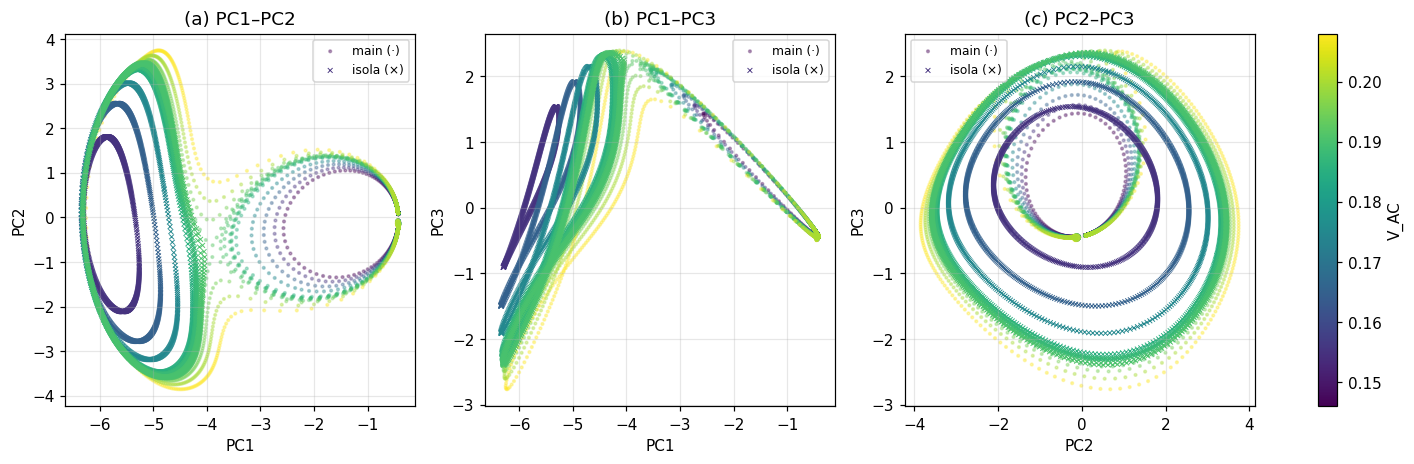

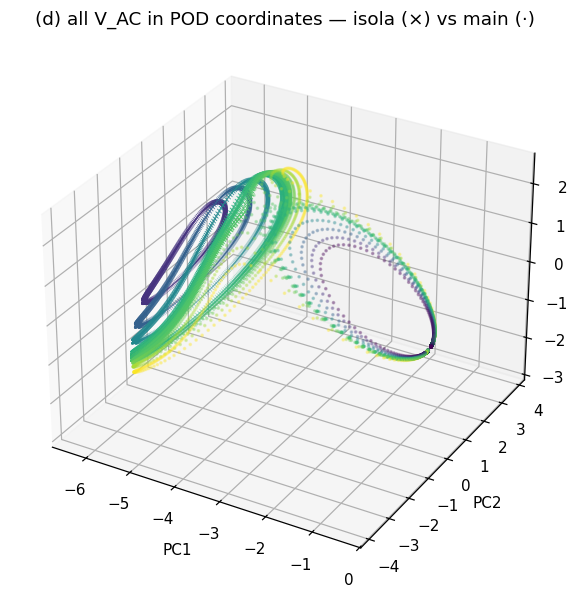

읽는 법: 색 = V_AC. (a) 오른쪽 작은 고리 = main 가지(저진폭 → 공진 → 위상 반전, V_AC 에 거의 무관하게 겹침).
        왼쪽의 닫힌 고리들 = isola(×): (Ω,A) 에서 닫힌 곡선이므로 POD 좌표에서도 닫힌 고리이고, V_AC 가 커질수록(보라→노랑) 고리가 커지며 오른쪽으로 다가간다.
        V_AC ≥ 0.192 의 main 점들(노란 ·) 은 두 고리를 잇는 '다리' 를 이룬다 = isola 가 main 에 흡수된 뒤의 한 가지.


In [14]:
# D-6b. PC 좌표 투영 — 교재 그림 1.17(난소암) 의 분기판 -----------------------------------
import matplotlib as mpl
vacs = sorted(G.VAC.unique()); norm = mpl.colors.Normalize(min(vacs), max(vacs)); cmap = plt.cm.viridis
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for (px, py), a in zip([("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")], ax):
    m_ = G.branch.eq("main")
    a.scatter(G.loc[m_, px], G.loc[m_, py], c=G.loc[m_, "VAC"], cmap=cmap, norm=norm, s=3, alpha=0.35, label="main (·)")
    a.scatter(G.loc[~m_, px], G.loc[~m_, py], c=G.loc[~m_, "VAC"], cmap=cmap, norm=norm, s=10, marker="x", linewidths=0.6, label="isola (×)")
    a.set_xlabel(px); a.set_ylabel(py); a.legend(fontsize=8, loc="best")
ax[0].set_title("(a) PC1–PC2"); ax[1].set_title("(b) PC1–PC3"); ax[2].set_title("(c) PC2–PC3")
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="V_AC", fraction=0.02)
plt.show()

# 3D 판 (PC1, PC2, PC3)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(7, 5.5)); a = fig.add_subplot(111, projection="3d")
m_ = G.branch.eq("main")
a.scatter(G.loc[m_, "PC1"], G.loc[m_, "PC2"], G.loc[m_, "PC3"], c=G.loc[m_, "VAC"], cmap=cmap, norm=norm, s=2, alpha=0.3)
a.scatter(G.loc[~m_, "PC1"], G.loc[~m_, "PC2"], G.loc[~m_, "PC3"], c=G.loc[~m_, "VAC"], cmap=cmap, norm=norm, s=8, marker="x", linewidths=0.6)
a.set_xlabel("PC1"); a.set_ylabel("PC2"); a.set_zlabel("PC3"); a.set_title("(d) all V_AC in POD coordinates — isola (×) vs main (·)")
plt.tight_layout(); plt.show()
print("읽는 법: 색 = V_AC. (a) 오른쪽 작은 고리 = main 가지(저진폭 → 공진 → 위상 반전, V_AC 에 거의 무관하게 겹침).\n"
      "        왼쪽의 닫힌 고리들 = isola(×): (Ω,A) 에서 닫힌 곡선이므로 POD 좌표에서도 닫힌 고리이고, V_AC 가 커질수록(보라→노랑) 고리가 커지며 오른쪽으로 다가간다.\n"
      "        V_AC ≥ 0.192 의 main 점들(노란 ·) 은 두 고리를 잇는 '다리' 를 이룬다 = isola 가 main 에 흡수된 뒤의 한 가지.")


,n_isola,A_max_main,min_PC_dist_isola_main,isola_Omega_span,isola_r999,isola_higher_harm_energy
VAC,,,,,,
0.146,0,0.2962,NaN,NaN,NaN,NaN
0.155,543,0.3157,2.5647,0.283,4,0.0893
0.165,515,0.3389,2.0098,0.4013,5,0.0937
0.175,468,0.3649,1.4994,0.4849,5,0.0971
0.185,534,0.3969,0.918,0.5522,6,0.1
0.1872,547,0.4057,0.7533,0.5661,6,0.1005
0.1874,548,0.4065,0.7373,0.5674,6,0.1005
0.188,552,0.4093,0.6863,0.5712,6,0.1007
0.19,452,0.4203,0.4802,0.5845,6,0.1011


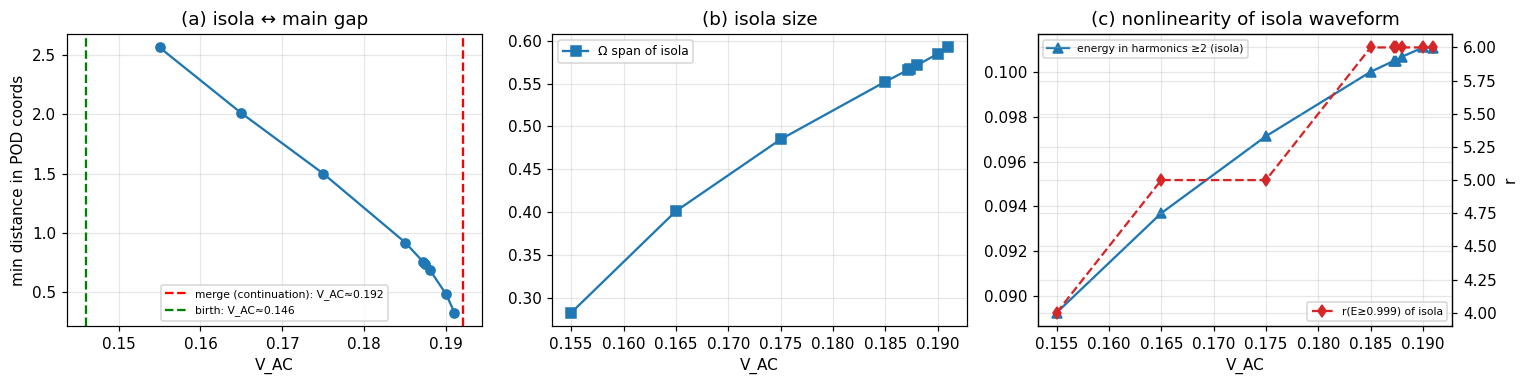

In [15]:
# D-6c. 정량 지표 — V_AC 에 따른 isola↔main 거리, isola 크기, isola 파형의 랭크 ------------------
from scipy.spatial.distance import cdist
rows = []
for vac, g in G.groupby("VAC"):
    iso, mn = g[g.branch.eq("isola")], g[g.branch.eq("main")]
    rec = dict(VAC=vac, n_isola=len(iso), A_max_main=mn.A.max())
    if len(iso):
        Pc = ["PC1", "PC2", "PC3", "PC4"]
        rec["min_PC_dist_isola_main"] = cdist(iso[Pc], mn[Pc]).min()          # 두 점군의 최근접 거리 (POD 좌표)
        rec["isola_Omega_span"] = iso.Omega.max() - iso.Omega.min()
        Xi = Phi @ iso[hbm_cols].to_numpy().T; si = np.linalg.svd(Xi, compute_uv=False); Ei = np.cumsum(si**2)/np.sum(si**2)
        rec["isola_r999"] = int(np.searchsorted(Ei, 0.999)+1)
        C = iso[hbm_cols].to_numpy(); h = np.array([C[:, 0]**2*2] + [C[:, 2*k-1]**2 + C[:, 2*k]**2 for k in range(1, NH+1)])
        rec["isola_higher_harm_energy"] = h[2:].sum()/h.sum()                   # 2차 이상 고조파 에너지 비율
    rows.append(rec)
T6 = pd.DataFrame(rows).set_index("VAC"); display(T6.round(4))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
t = T6.dropna()
ax[0].plot(t.index, t.min_PC_dist_isola_main, "o-"); ax[0].axvline(0.192, color="r", ls="--", label="merge (continuation): V_AC≈0.192"); ax[0].axvline(0.146, color="g", ls="--", label="birth: V_AC≈0.146")
ax[0].set_xlabel("V_AC"); ax[0].set_ylabel("min distance in POD coords"); ax[0].set_title("(a) isola ↔ main gap"); ax[0].legend(fontsize=7)
ax[1].plot(t.index, t.isola_Omega_span, "s-", label="Ω span of isola"); ax[1].set_xlabel("V_AC"); ax[1].set_title("(b) isola size"); ax[1].legend(fontsize=8)
ax[2].plot(t.index, t.isola_higher_harm_energy, "^-", label="energy in harmonics ≥2 (isola)"); ax2 = ax[2].twinx(); ax2.plot(t.index, t.isola_r999, "d--", color="C3", label="r(E≥0.999) of isola"); ax2.set_ylabel("r"); 
ax[2].set_xlabel("V_AC"); ax[2].set_title("(c) nonlinearity of isola waveform"); ax[2].legend(fontsize=7, loc="upper left"); ax2.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()


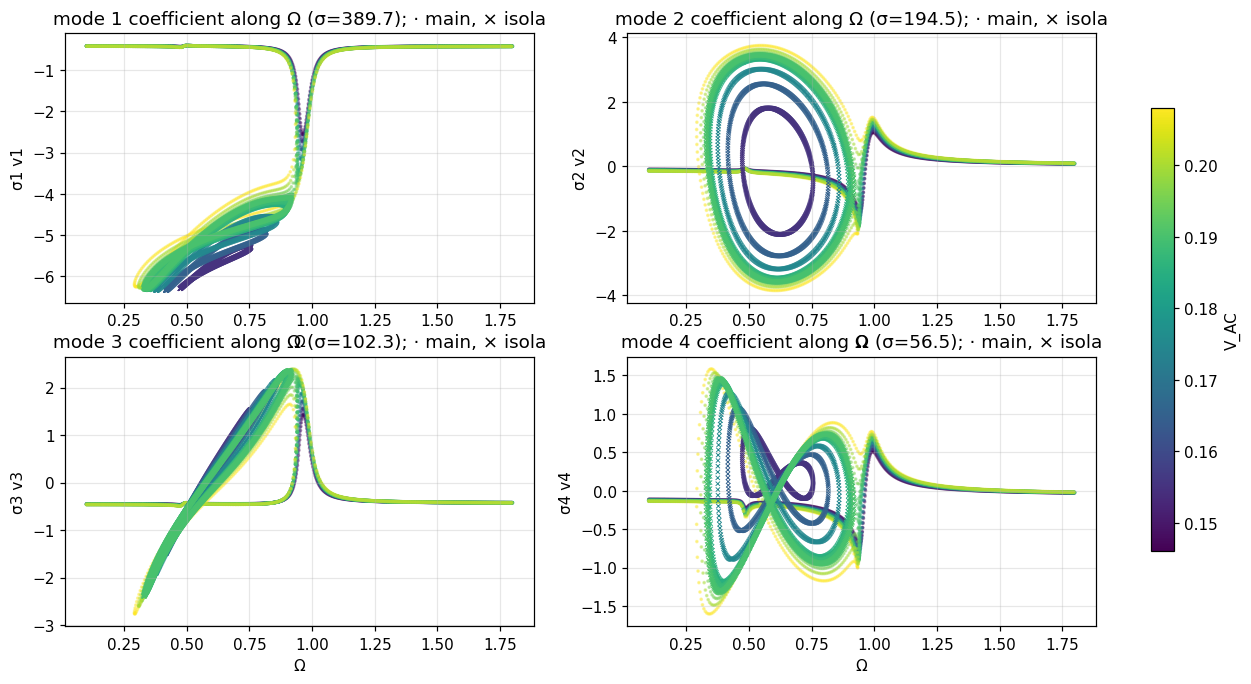

읽는 법: 각 패널은 FRC(Ω–A) 를 '모드 k 의 진폭' 으로 다시 그린 것. isola(×) 는 모드 면 위의 고립된 조각이며, V_AC 가 커질수록 main 의 공진 봉우리와 이어진다.


In [16]:
# D-6d. 모드 계수 면 σ_k v_k(Ω, V_AC) — 모드별로 분해한 FRC ---------------------------------
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
for k, a in enumerate(ax.ravel()):
    pc = f"PC{k+1}"; m_ = G.branch.eq("main")
    a.scatter(G.loc[m_, "Omega"], G.loc[m_, pc], c=G.loc[m_, "VAC"], cmap=cmap, norm=norm, s=2, alpha=0.4)
    a.scatter(G.loc[~m_, "Omega"], G.loc[~m_, pc], c=G.loc[~m_, "VAC"], cmap=cmap, norm=norm, s=8, marker="x", linewidths=0.6)
    a.set_xlabel("Ω"); a.set_ylabel(f"σ{k+1} v{k+1}"); a.set_title(f"mode {k+1} coefficient along Ω (σ={s_G[k]:.1f}); · main, × isola")
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="V_AC", fraction=0.02)
plt.show()
print("읽는 법: 각 패널은 FRC(Ω–A) 를 '모드 k 의 진폭' 으로 다시 그린 것. isola(×) 는 모드 면 위의 고립된 조각이며, V_AC 가 커질수록 main 의 공진 봉우리와 이어진다.")


**D-6 해석.**
* (D-6b) POD 좌표에서 main 가지는 $V_{AC}$에 거의 무관한 하나의 작은 고리(저진폭 → 공진 → 위상 반전)로 겹치고, isola는 그와 떨어진 **닫힌 고리**다((Ω, A)에서 닫힌 곡선이므로). $V_{AC}$가 커질수록 isola 고리가 커지며 main 고리 쪽으로 다가가고, $V_{AC}\ge0.192$의 main 점들은 두 고리를 잇는 다리를 이룬다 — 연속법이 준 "merge"가 파형 좌표에서 연속적인 접근과 연결로 보인다. PC2–PC3 면에서는 isola 고리들이 동심원처럼 커지는 모습이 가장 선명하다.
* (D-6c-a) isola↔main의 POD 최근접 거리는 $V_{AC}$ 0.155 → 0.191에서 단조 감소해 합쳐지는 0.192에서 0이 된다. 거리가 0이 되는 지점은 연속법의 소멸 전압과 일치 — **SVD가 분기를 찾은 것이 아니라, 분기 구조가 데이터 기저 위에서 거리 0으로 표현된다**는 확인이다. 탄생 쪽(0.146)은 HBM 계수 파일이 없어 0.155의 작은 isola부터 보인다; 외삽하면 거리가 가장 큰 쪽이 탄생 직후다(막 태어난 isola는 main과 가장 다른 파형).
* (D-6c-b,c) isola는 $V_{AC}$와 함께 Ω 폭이 커지고(0.28 → 0.59), 2차 이상 고조파 에너지 비율은 8.9 % → 10.1 %, 필요한 랭크 $r(E\ge0.999)$는 4 → 6으로 완만히 는다 — isola 파형의 비선형성은 $V_{AC}$에 약하게만 민감하고, 크게 변하는 것은 "어느 Ω 범위에 존재하는가"다.
* (D-6d) 모드 계수 면은 FRC를 모드별로 분해한 것이며, isola는 각 모드 면 위의 고립된 조각으로 나타난다. 특히 고조파가 섞인 모드 3·4에서 isola와 main의 분리가 가장 뚜렷하다 — 진폭 $A$만 보는 기존 FRC 그림보다 isola를 구별하기 좋은 좌표다.
* 한계: 균등 추출(≈450점/가지)에 따라 특이값 크기는 달라지지만 PC 좌표의 상대 배치는 바뀌지 않음을 `N_PER`를 바꿔 확인할 수 있다; 분기점(SN) 위치나 미계산 $V_{AC}$의 isola 존재 여부는 이 방법으로 얻을 수 없다.


### D-7. 요약

| 항목 | 결과 |
|---|---|
| $X$ | $256\times5445$ (행: 위상 표본, 열: FRC 연속점 = main 3189 + isola 2256), 위상 정규화로 정렬됨 |
| 수치 랭크 | ≤ 27 $=2N_H+1$ (main 23, isola 27) — $X=\Phi C$의 상한, $\sigma_{28}$부터 $10^{-13}$ 반올림 바닥; 가우시안 잡음이 아니라 경판정은 부적합 |
| 절단 랭크 | main: $r=3$ (DC + 1차 cos/sin, $E=0.9993$); isola: $r=6$ ($E\ge0.999$, 엘보 6–7); 전체: $r=7$ |
| 공식–실측 | (2)의 Frobenius·2-노름 공식이 실측과 $10^{-6}$ 이내 일치 |
| $V_{AC}$ 전체 앙상블 (D-6) | 14개 $V_{AC}$·모든 가지를 한 행렬로: POD 좌표에서 isola 점군이 main 고리에 접근해 0.192에서 거리 0(merge)으로 — 분기 구조의 시각화(검출은 아님) |
| 고정 vs 데이터 기저 | main: Fourier $K=1$ ≈ SVD $r=3$ (고정 기저로 충분); isola: 같은 저장량에서 SVD 오차가 Fourier의 1/2–1/5 — "파형이 변하는 정렬된 진동 응답 앙상블은 데이터 기저가 낫다" 확인; HBM 계수는 Fourier 기저에서 $K$-희소(main $K\approx1$, isola $K\approx4$–5) |


## AI 사용 명세

사용 도구: Claude (Anthropic). 노트북 구성·코드 초안·D 데이터 선정 논의에 사용했고, 아래 표는 실제로 던진 질문의 로그와 교재(식 번호)와 대조해 확인·수정한 지점이다. 코드는 모두 직접 실행해 수치를 확인했다.

### 1. 질문 로그 — 노트북 구성 (A·B·D)

| # | 질문 | 교재와 대조해 확인·수정한 지점 |
|---|---|---|
| 1 | W02 강의노트의 과제 A–D를 한 .ipynb에 담되, 2주차 정리로 시작해 A→B→C→D 순으로 문제·코드·결과를 배치해 달라. | 과제 요구사항(손유도 필수, A 필수, B 택1, D 필수)을 강의노트 15쪽과 대조. 2-노름 오차 $\sigma_{r+1}$은 numpy 0-base에서 `s[r]`임을 확인 [식 (2)]. |
| 2 | D에 쓸 데이터 행렬을 `result_0819`의 많은 파일 중 하나 고르되, 4주차 내용도 참고해 SVD에 의미가 있는 것으로 선택해 달라. SVD와 관련이 없으면 D를 빼고 다시 말해 달라. | HBM 계수 → 주기응답 스냅샷 행렬(행 = 위상, 열 = 연속점)로 정의하면 교재 §1.1–1.3의 POD 설정과 같음. 4주차 §1.1의 "Fourier = 범용 희소 기저 / SVD = 맞춤 기저"를 D-4의 비교 축으로 채택. |
| 3 | C는 배포 풀이 파일이 없어 제외하고 관련 내용을 모두 지워 달라; 작성자 이름 수정. | — |
| 4 | (b) 방향(여러 $V_{AC}$를 열로 쌓기)으로 SVD를 하면 isola의 탄생–소멸을 볼 수 있는가? | AI 답: "보인다"는 맞지만 SVD가 분기를 *찾는* 것은 아니며 연속법 결과를 파형 좌표로 *표현*할 뿐. 교재 §1.5(PCA 좌표 투영, 난소암 예제)의 사용법과 같음을 확인하고 D-6에 그 한계를 명시. |
| 5 | A의 `my_photo.jpg`는 무엇인가, 내가 만들어야 하는가? → 파일명을 `mongehodu.jpg`로 변경. | 과제 A "자기 사진에 적용"의 뜻 확인 (교재 Code 1.1의 개 사진 자리). |
| 6 | D-1~D-6 각 결과가 무슨 의미인지 설명해 달라. | 아래 "2. D 관련 세부 질문"에 정리. |
| 7 | 노트북을 GitHub에 올리면 실행 결과(그림)까지 보이는가? 올리는 순서는? | 출력이 저장된 .ipynb는 GitHub가 렌더링함(크면 nbviewer). 과제 제출 형식(공개 연구노트 링크)과 대조. |

### 2. 질문 로그 — D 관련 세부 질문과 확인 지점

| # | 질문 | 확인·수정한 지점 (교재 대조) |
|---|---|---|
| D-1 | HBM 계수 27개를 그대로 X로 쓰는 것과 시간 영역 파형(256점)으로 재구성해 쓰는 것은 무엇이 다른가? | $X=\Phi C$이고 $\Phi$의 열이 직교이므로 두 SVD의 특이값은 상수배로 같다(§1.1 식 (1)). 파형 쪽을 택한 이유는 모드 $u_k(\tau)$가 "파형"으로 읽혀 교재의 POD 해석(§1.3)과 맞기 때문. |
| D-1 | 행·열의 뜻, 크기, 정렬 여부를 과제가 요구하는데 이 데이터는 "정렬"됐다고 할 수 있는가? | 위상 $\tau=\Omega t$로 정규화 → 정렬. 단 가진력 기준 위상 지연 $\phi(\Omega)$가 변하므로 §1.6의 "회전"과 같은 효과가 남음 → D-5로 검증. |
| D-2 | 수치 랭크가 main 23, isola 27로 다른 이유는? | $X=\Phi C$의 랭크 상한 $2N_H+1=27$. main은 10차 이상 고조파가 $10^{-10}\sigma_1$ 아래라 23. 교재 §1.7의 "저랭크 구조"가 여기서는 HBM 차수에서 오는 구조적 상한임을 확인. |
| D-2 | 경판정(Gavish–Donoho)을 적용했더니 r ≈ 35–39가 나오는데 왜 27보다 큰가? | B&K (1.44)–(1.47)은 가우시안 잡음 가정. 여기 바닥은 반올림($10^{-13}$)이라 $\sigma_{\rm med}$가 바닥 안에 있어 $\tau$가 무의미. 절단은 에너지·엘보·$\sigma_{27}\to\sigma_{28}$ 낙차로 정함. 실험 데이터면 센서 잡음이 바닥이 되어 경판정이 유효. |
| D-2 | main은 r = 3, isola는 r = 6인데 그 물리적 의미는? | main: DC 처짐 $a_0$ + 1차 조화 cos/sin = 선형 공진기와 같음. isola: 2·3차 고조파 에너지(≈9 %, 1.3 %)가 모드로 더 필요. $H_{\rm ratio}$(bifurcation_points.txt)와 일치. |
| D-3 | 식 (2)의 $\sqrt{1-E(r)}$ 꼴로 계산하면 r = 27에서 실측과 안 맞는다. 왜? | $E\to1$에서 $1-E$의 자릿수 손실(catastrophic cancellation). $\sqrt{\sum_{k>r}\sigma_k^2}/\|X\|_F$ 꼴로 바꾸면 $10^{-15}$까지 일치. 수식은 동치지만 수치 구현은 다름 — 교재 식 (1.17)의 두 표현 중 후자를 코드에 사용. |
| D-3 | 에너지 99.9 %인데 점별 최대 오차가 진폭의 10 %나 되는 이유? | Frobenius는 평균적 오차; 최대 오차는 고조파가 센 isola 끝단 스냅샷에 집중. 2주차 경고("에너지 99 % ≠ 오차 1 %")의 점별 판. |
| D-3b | POD 모드 $u_1,u_2,u_3$가 DC와 1차 조화의 "섞임"인 이유는? 왜 깔끔히 DC / cos / sin으로 안 나뉘나? | SVD는 분산이 큰 방향을 잡을 뿐 물리적 성분을 분리하지 않음(§1.5 PCA 해석). 데이터에서 $a_0$와 $a_1$이 Ω에 따라 함께 변하므로 상관된 방향이 한 모드로 묶임. |
| D-4 | 저장량 비교에서 "r = 2K+1이 같은 저장량"이 되는 근거는? | SVD 저장 $r(n+m+1)$, Fourier 저장 $m(2K+1)$; $m\gg n$이면 $r\,m \approx m(2K+1)$. 교재 (1.11)의 저장 개수 계산을 그대로 적용. |
| D-4 | main에서는 Fourier와 SVD가 거의 같은데 isola에서는 SVD가 이기는 이유는? | main은 파형이 거의 1차 조화 하나라 고정 기저가 이미 최적(표 2: "매끄러운 신호는 Fourier"). isola는 고조파 비율이 Ω에 따라 변해 "진폭 순 재조합"(데이터 기저)이 유리. 교재 §2.7 그림 13(b) 논리의 진동판. |
| D-4 | 4주차의 $K$-희소 개념과 어떻게 연결되나? | HBM 계수 벡터는 Fourier 기저에서 $K$-희소(main $K\approx1$, isola $K\approx4$–5) [B&K (3.1)]. 압축센싱은 이 희소성을 "측정을 줄이는 데" 쓰고, 여기서는 "저장을 줄이는 데" 씀 (§3.1 압축 vs 압축센싱). |
| D-5 | 위상을 정렬하면 왜 isola가 6 → 3으로 main(3 → 2)보다 더 많이 줄어드나? | 1차 위상 $\phi_1$로 돌리면 $k$차 고조파는 $k\phi_1$만큼 함께 회전 → 고조파가 많은 isola에서 "회전에 의한 가짜 차원"이 더 많이 풀림. §1.6의 회전된 정사각형(랭크 1 → 176)과 같은 메커니즘. |
| D-5 | 그렇다면 항상 정렬해서 쓰는 게 맞나? | 아니다. FRC 위상 곡선이 분석 대상이면 정렬은 정보 손실. 교재 §1.6도 "정렬이 되어 있을 때 데이터 기저가 유리"라고 할 뿐, 정렬이 항상 옳다고 하지 않음. |
| D-6 | 모든 $V_{AC}$를 쌓은 SVD로 isola의 탄생–소멸을 "볼" 수 있는가? | 볼 수 있다(PC 좌표에서 isola 고리가 main 고리에 접근해 0.192에서 연결). 그러나 분기 자체는 연속법이 정한 것이고 SVD는 그 좌표화일 뿐 — 미계산 $V_{AC}$의 isola 존재나 SN 위치는 얻지 못함. |
| D-6 | $V_{AC}$마다 점 수가 다른데 그냥 쌓아도 되나? | 안 됨. 합쳐진 뒤 main 가지는 5500점이라 특이값을 지배. (가지, $V_{AC}$)당 ≈450점 균등 추출. 추출 수는 특이값 크기만 바꾸고 PC 배치는 안 바꿈을 `N_PER`로 확인. |
| D-6 | $V_{AC}$ = 0.146(탄생)은 왜 isola가 안 보이나? | 막 태어난 isola는 점이 몇 개뿐이라 HBM 계수 파일이 저장되지 않음(FRC_CNT_branch02만 존재). 탄생 쪽은 0.155부터. 보완하려면 0.146의 HBM 계수를 저장해야 함. |
| D-6 | PC 좌표에서 isola가 "닫힌 고리"로 보이는 이유는? | isola는 (Ω, A)에서 닫힌 곡선이므로 연속점의 파형이 한 바퀴 돌아 제자리로 옴 → 어떤 선형 좌표에서도 닫힌 고리. main은 Ω 0.1 → 1.8의 열린 경로지만 저진폭 양 끝 파형이 비슷해 고리처럼 보임. |
| D-6 | isola↔main 거리가 0.192에서 0이 되는 것을 "merge 검출"이라고 써도 되나? | 쓰면 안 됨. 거리는 연속법이 준 점들 사이의 거리이고, 0.192에서 0이 되는 건 그 $V_{AC}$에서 연속법이 한 가지로 계산했기 때문. "분기 구조가 데이터 기저 위에서 거리 0으로 표현된다"로 서술. |
| D-6 | 모드 3·4 계수 면에서 isola와 main이 가장 잘 갈리는 이유는? | 모드 3·4는 2Ω·3Ω 고조파를 담는 모드(D-3b 히트맵). isola 파형의 특징이 고조파이므로 그 모드의 계수에서 분리가 큼. 진폭 $A$(≈ 모드 1·2)만 보는 FRC보다 구별력이 좋은 좌표. |
| D-6 | 이 결과는 4주차·7주차와 어떻게 이어지나? | 같은 재구성 $x(\tau)$와 HBM에서 해석적으로 얻는 $\dot x,\ddot x$로 후보항 라이브러리 $\Theta$를 만들어 STLSQ(4주차 §2.6)로 운동방정식 복원 → Part B #3. $V_{AC}$ 앙상블의 POD 좌표는 7주차 DMD/파라메트릭 축소모델의 좌표로 재사용 가능(표 2 "다음 주와의 연결"). |

### 3. AI 답변 중 틀렸거나 보완한 지점

| # | AI의 초기 답 | 수정 |
|---|---|---|
| 1 | D-4 해석에서 "같은 저장량에서 SVD가 항상 Fourier보다 오차가 낮다"고 서술 | 실행 결과 main에서는 두 곡선이 겹치고 r = 1, 2에서는 SVD가 오히려 불리 → "파형이 변하는 앙상블에서만 데이터 기저가 유리"로 수정. |
| 2 | D-2에서 "경판정이 27개를 남긴다"고 서술 | 실제 r_hard ≈ 35–39. 반올림 바닥 안에 $\tau$가 놓여 무의미함을 확인하고 서술 수정. |
| 3 | D-5에서 "정렬하면 랭크가 1 줄어든다"고 서술 | 실행 결과 main 3 → 2, isola 6 → 3. 고조파의 $k\phi_1$ 회전까지 풀리는 효과를 추가 설명. |
| 4 | D-3 오차 공식을 $\sqrt{1-E(r)}$로 구현 | r = 27에서 자릿수 손실로 실측과 불일치 → $\sqrt{\sum_{k>r}\sigma_k^2}/\|X\|_F$로 교체. |
| 5 | B의 해석에서 $\gamma=2$이면 경판정이 r = 1로 떨어질 "수 있다"고 서술 | 실행 결과 $\sigma_2\approx145>\tau\approx113$으로 r = 2 유지, 단 $\sigma_3\approx98$이 $\tau$ 직하 → 여유가 거의 없음으로 수정. |

